## Exploración datos Capstone + cuánta segmentación usar
## (Data con taxi amarillos)


### Pre análisis:

In [1]:
pip install pandas matplotlib seaborn pyarrow

Note: you may need to restart the kernel to use updated packages.


#### Zonas de manhattan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

manhattan_ids = [4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79,
                 87, 88, 90, 100, 103, 104, 105, 106, 107, 113, 114,
                 116, 120, 125, 127, 128, 137, 140, 141, 142, 143,
                 144, 148, 151, 152, 153, 158, 161, 162, 163, 164,
                 166, 170, 186, 202, 209, 211, 224, 229, 230, 231,
                 232, 233, 234, 236, 237, 238, 239, 243, 244, 246, 249,
                 261, 262, 263]

#print(df.head())

In [3]:
len(manhattan_ids)

67

#### Filtrar y unir base de datos del 2024 y 2025 de taxi amarillos:

In [4]:
import os

In [5]:
import glob

ruta_taxi = "/Users/jmatas/OneDrive/Universidad/8vo semestre/Capstone/Datos taxi amarillo/2024"
meses_2024 = ["07","08","09","10","11","12"]
archivos_taxi_2024 = [os.path.join(ruta_taxi, f"yellow_tripdata_2024-{m}.parquet")
                      for m in meses_2024]
dfs = []
for archivo in archivos_taxi_2024:
    df_temp = pd.read_parquet(archivo)
    df_temp = df_temp[
        (df_temp["PULocationID"].isin(manhattan_ids)) & 
        (df_temp["DOLocationID"].isin(manhattan_ids))
    ].copy()
    df_temp['tpep_pickup_datetime'] = pd.to_datetime(df_temp['tpep_pickup_datetime'])
    df_temp['month'] = df_temp['tpep_pickup_datetime'].dt.month
    df_temp['weekday'] = df_temp['tpep_pickup_datetime'].dt.day_name()
    dfs.append(df_temp)

df_all_taxi_2024 = pd.concat(dfs, ignore_index=True)
df_all_taxi_2024 = df_all_taxi_2024[df_all_taxi_2024['month'].between(7, 12)]
demanda_2024_taxi = df_all_taxi_2024.groupby(['month', 'weekday']).size().reset_index(name='count')
viajes_por_mes_taxi_2024 = df_all_taxi_2024['month'].value_counts().sort_index()
print(viajes_por_mes_taxi_2024)

month
7     2398529
8     2294504
9     2828653
10    3000441
11    2879470
12    2882393
Name: count, dtype: int64


In [6]:
ruta_taxi = "/Users/jmatas/OneDrive/Universidad/8vo semestre/Capstone/Datos taxi amarillo/2025"
archivos_taxi_2025 = sorted(glob.glob(f"{ruta_taxi}/yellow_tripdata_2025-0[1-6].parquet"))
dfs = []
for archivo in archivos_taxi_2025:
    df_temp = pd.read_parquet(archivo)
    df_temp = df_temp[
        (df_temp["PULocationID"].isin(manhattan_ids)) & 
        (df_temp["DOLocationID"].isin(manhattan_ids))
    ].copy()
    df_temp['tpep_pickup_datetime'] = pd.to_datetime(df_temp['tpep_pickup_datetime'])
    df_temp['month'] = df_temp['tpep_pickup_datetime'].dt.month
    df_temp['weekday'] = df_temp['tpep_pickup_datetime'].dt.day_name()
    dfs.append(df_temp)

df_all_taxi_2025 = pd.concat(dfs, ignore_index=True)
df_all_taxi_2025 = df_all_taxi_2025[df_all_taxi_2025['month'].between(1, 6)]
demanda_2025_taxi = df_all_taxi_2025.groupby(['month', 'weekday']).size().reset_index(name='count')
viajes_por_mes_taxi_2025 = df_all_taxi_2025['month'].value_counts().sort_index()
print(viajes_por_mes_taxi_2025)

month
1    2776626
2    2845540
3    3204159
4    3071232
5    3464634
6    3232329
Name: count, dtype: int64


In [7]:
# Agregar columna de año a cada base
df_all_taxi_2024['year'] = 2024
df_all_taxi_2025['year'] = 2025
# Unir bases
df_all_taxi = pd.concat([df_all_taxi_2024, df_all_taxi_2025], ignore_index=True)
#print("Tamaño total:", len(df_all_taxi))
#print("Por año:\n", df_all_taxi['year'].value_counts().sort_index())
print("Por mes:\n", df_all_taxi.groupby(['year','month']).size())

Por mes:
 year  month
2024  7        2398529
      8        2294504
      9        2828653
      10       3000441
      11       2879470
      12       2882393
2025  1        2776626
      2        2845540
      3        3204159
      4        3071232
      5        3464634
      6        3232329
dtype: int64


In [8]:
# Renombrar columnas clave para igualarlas con la de FHV
df_all_taxi = df_all_taxi.rename(columns={
    "tpep_pickup_datetime": "pickup_datetime",
    "tpep_dropoff_datetime": "dropOff_datetime",
    "PULocationID": "PUlocationID",
    "DOLocationID": "DOlocationID"
})
# Seleccionar solo las columnas que nos interesan
df_all_taxi = df_all_taxi[[
    "pickup_datetime", "dropOff_datetime", "PUlocationID", "DOlocationID", "month", "weekday", "year"
]]

#### Filtrar y unir base de datos de 2024 y 2025 de FHV:

In [9]:
# Cargar y unir los 6 archivos de meses
archivos = sorted(glob.glob("Datos/fhv_tripdata_2025-0[1-6].parquet"))
dfs = []
for archivo in archivos:
    df_temp = pd.read_parquet(archivo)
    df_temp = df_temp[
        (df_temp["PUlocationID"].isin(manhattan_ids)) & 
        (df_temp["DOlocationID"].isin(manhattan_ids))
    ].copy()
    df_temp['pickup_datetime'] = pd.to_datetime(df_temp['pickup_datetime'])
    df_temp['month'] = df_temp['pickup_datetime'].dt.month
    df_temp['weekday'] = df_temp['pickup_datetime'].dt.day_name()
    dfs.append(df_temp)
df_all = pd.concat(dfs, ignore_index=True)

In [10]:
ruta = "/Users/jmatas/OneDrive/Universidad/8vo semestre/Capstone/Datos 2024"
archivos_2024 = sorted(glob.glob(f"{ruta}/fhv_tripdata_2024-*.parquet"))
dfs = []
for archivo in archivos_2024:
    df_temp = pd.read_parquet(archivo)
    df_temp = df_temp[
        (df_temp["PUlocationID"].isin(manhattan_ids)) & 
        (df_temp["DOlocationID"].isin(manhattan_ids))
    ].copy()
    df_temp['pickup_datetime'] = pd.to_datetime(df_temp['pickup_datetime'])
    df_temp['month'] = df_temp['pickup_datetime'].dt.month
    df_temp['weekday'] = df_temp['pickup_datetime'].dt.day_name()
    dfs.append(df_temp)
df_all_2024 = pd.concat(dfs, ignore_index=True)

In [11]:
# Limpiar y agregar columna year
fhv_2024_clean = df_all_2024[['pickup_datetime','dropOff_datetime',
                              'PUlocationID','DOlocationID','month','weekday']].copy()
fhv_2024_clean['year'] = fhv_2024_clean['pickup_datetime'].dt.year
fhv_2024_clean = fhv_2024_clean[fhv_2024_clean['month'].between(7,12)]

fhv_2025_clean = df_all[['pickup_datetime','dropOff_datetime',
                         'PUlocationID','DOlocationID','month','weekday']].copy()
fhv_2025_clean['year'] = fhv_2025_clean['pickup_datetime'].dt.year
fhv_2025_clean = fhv_2025_clean[fhv_2025_clean['month'].between(1,6)]

# Concatenar en uno solo
fhv_all = pd.concat([fhv_2024_clean, fhv_2025_clean], ignore_index=True)

# Chequeo rápido
#print(fhv_all.info())
print(fhv_all[['year','month']].value_counts().sort_index())

year  month
2024  7        53148
      8        11668
      9        51152
      10       49418
      11       54238
      12       12130
2025  1        51450
      2        44205
      3        15195
      4        42652
      5        48827
      6        46659
Name: count, dtype: int64


#### Unimos la bd de fhv con taxi amarillos

In [12]:
# 1) FHV 
fhv_all['tipo'] = 'fhv'
# 2) Taxi amarillo
df_all_taxi['tipo'] = 'taxi'
# 3) Unir ambas bases
df_all = pd.concat([fhv_all, df_all_taxi], ignore_index=True)

# 4) Chequeo rápido
print(df_all['tipo'].value_counts())
print(df_all[['year','month','tipo']].value_counts().sort_index())

tipo
taxi    34878510
fhv       480742
Name: count, dtype: int64
year  month  tipo
2024  7      fhv       53148
             taxi    2398529
      8      fhv       11668
             taxi    2294504
      9      fhv       51152
             taxi    2828653
      10     fhv       49418
             taxi    3000441
      11     fhv       54238
             taxi    2879470
      12     fhv       12130
             taxi    2882393
2025  1      fhv       51450
             taxi    2776626
      2      fhv       44205
             taxi    2845540
      3      fhv       15195
             taxi    3204159
      4      fhv       42652
             taxi    3071232
      5      fhv       48827
             taxi    3464634
      6      fhv       46659
             taxi    3232329
Name: count, dtype: int64


#### df_all es la base de datos con la que se trabajará

Filtrar solo meses de primavera y otoño según calendario meteorológico

In [13]:
# Filtrar df_all solo para primavera y otoño (calendario meteorológico)
#df_all = df_all[df_all["month"].isin([3,4,5,9,10,11])].copy()
#print("Número de filas después del filtro:", len(df_all))

In [14]:
print(df_all['tipo'].value_counts())
print(df_all[['year','month','tipo']].value_counts().sort_index())

tipo
taxi    34878510
fhv       480742
Name: count, dtype: int64
year  month  tipo
2024  7      fhv       53148
             taxi    2398529
      8      fhv       11668
             taxi    2294504
      9      fhv       51152
             taxi    2828653
      10     fhv       49418
             taxi    3000441
      11     fhv       54238
             taxi    2879470
      12     fhv       12130
             taxi    2882393
2025  1      fhv       51450
             taxi    2776626
      2      fhv       44205
             taxi    2845540
      3      fhv       15195
             taxi    3204159
      4      fhv       42652
             taxi    3071232
      5      fhv       48827
             taxi    3464634
      6      fhv       46659
             taxi    3232329
Name: count, dtype: int64


In [15]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [16]:
#eliminar feriado usa de df_all
import pandas as pd
import holidays

# Asegurar datetime
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['date'] = df_all['pickup_datetime'].dt.date

# Crear conjunto de feriados en USA (ej: New York)
us_holidays = holidays.US(years=df_all['pickup_datetime'].dt.year.unique(), state='NY')
# Filtrar quitando feriados
df_all = df_all[~df_all['date'].isin(us_holidays)]

In [17]:
print(df_all['tipo'].value_counts())
print(df_all[['year','month','tipo']].value_counts().sort_index())

tipo
taxi    33856858
fhv       465722
Name: count, dtype: int64
year  month  tipo
2024  7      fhv       52075
             taxi    2352571
      8      fhv       11668
             taxi    2294504
      9      fhv       50284
             taxi    2775439
      10     fhv       48341
             taxi    2924159
      11     fhv       50296
             taxi    2670128
      12     fhv       11993
             taxi    2841849
2025  1      fhv       49938
             taxi    2647813
      2      fhv       40061
             taxi    2550326
      3      fhv       15195
             taxi    3204159
      4      fhv       42652
             taxi    3071232
      5      fhv       48108
             taxi    3402268
      6      fhv       45111
             taxi    3122410
Name: count, dtype: int64


In [18]:
import pandas as pd
import holidays

# Asegurar fecha
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['date'] = df_all['pickup_datetime'].dt.date

# --- Generar feriados USA (ejemplo: 2024 y 2025) ---
us_holidays = holidays.US(years=[2024, 2025])

# Fechas únicas antes
dias_totales = df_all['date'].nunique()

# Filtrar quitando feriados
df_no_holidays = df_all[~df_all['date'].isin(us_holidays)]

# Fechas únicas después
dias_filtrados = df_no_holidays['date'].nunique()

# Diferencia
print(f"Días totales: {dias_totales}")
print(f"Días después de quitar feriados: {dias_filtrados}")
print(f"Días eliminados (feriados): {dias_totales - dias_filtrados}")

Días totales: 353
Días después de quitar feriados: 353
Días eliminados (feriados): 0


----------------------------------------------
----------------------------------------------
<br><br>

#### Análisis:

#### ¿Cuánta segmentación usar (día, hora, semana, mes ...) sin quedarnos sin datos ni sobre complicar? ¿Qué factores explican la variación de demanda? 

#### ¿Basta con OD x hora x día? ¿O necesito tmb distinguir por semanas o meses?

In [19]:
# Agrupar por mes y día de la semana
demanda = df_all.groupby(['month', 'weekday']).size().reset_index(name='count')

In [20]:
demanda.head(50)

,month,weekday,count
0,1,Friday,480092
1,1,Monday,217315
2,1,Saturday,399188
3,1,Sunday,315361
4,1,Thursday,506086
5,1,Tuesday,374414
6,1,Wednesday,405295
7,2,Friday,470081
8,2,Monday,236461
9,2,Saturday,365398


In [21]:
df_all['pickup_datetime'].dt.date.value_counts().sort_index()

pickup_datetime
2002-12-31         1
2008-12-31         2
2024-07-01     65149
2024-07-02     70131
2024-07-03     63377
               ...  
2025-06-26    118595
2025-06-27    104754
2025-06-28    107954
2025-06-29     90700
2025-06-30     85500
Name: count, Length: 353, dtype: int64

In [22]:
viajes_por_mes = df_all['month'].value_counts().sort_index()
print(viajes_por_mes)

month
1     2697751
2     2590387
3     3219354
4     3113884
5     3450376
6     3167521
7     2404646
8     2306172
9     2825723
10    2972500
11    2720424
12    2853842
Name: count, dtype: int64


-----------------------------------------------------
-----------------------------------------------------

In [23]:
df_all['date'] = df_all['pickup_datetime'].dt.date

In [24]:
viajes_por_dia = (
    df_all
    .groupby(['month','date','weekday'])
    .size()
    .reset_index(name='count')
)

In [25]:
promedio_semana = (
    viajes_por_dia
    .groupby(['month','weekday'])['count']
    .mean()
    .reset_index(name='promedio_viajes')
)

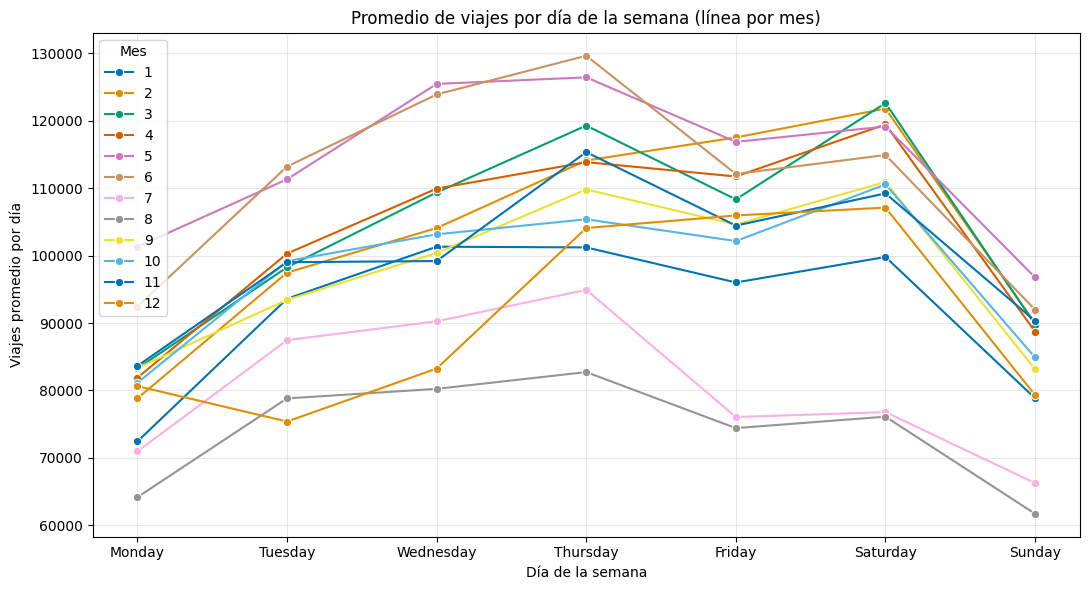

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Orden de días (en inglés si tus columnas están así)
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Asegurar tipo categórico ordenado para el eje X
promedio_semana = promedio_semana.copy()
promedio_semana['weekday'] = pd.Categorical(promedio_semana['weekday'], categories=dias_orden, ordered=True)

plt.figure(figsize=(11,6))
sns.lineplot(
    data=promedio_semana.sort_values(['month','weekday']),
    x='weekday', y='promedio_viajes',
    hue='month', marker='o', palette='colorblind'
)
plt.title('Promedio de viajes por día de la semana (línea por mes)')
plt.xlabel('Día de la semana')
plt.ylabel('Viajes promedio por día')
plt.xticks(rotation=0)
plt.legend(title='Mes', loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Diccionario de traducción
dias_map = {
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
}

In [28]:
promedio_semana['weekday'] = promedio_semana['weekday'].map(dias_map)

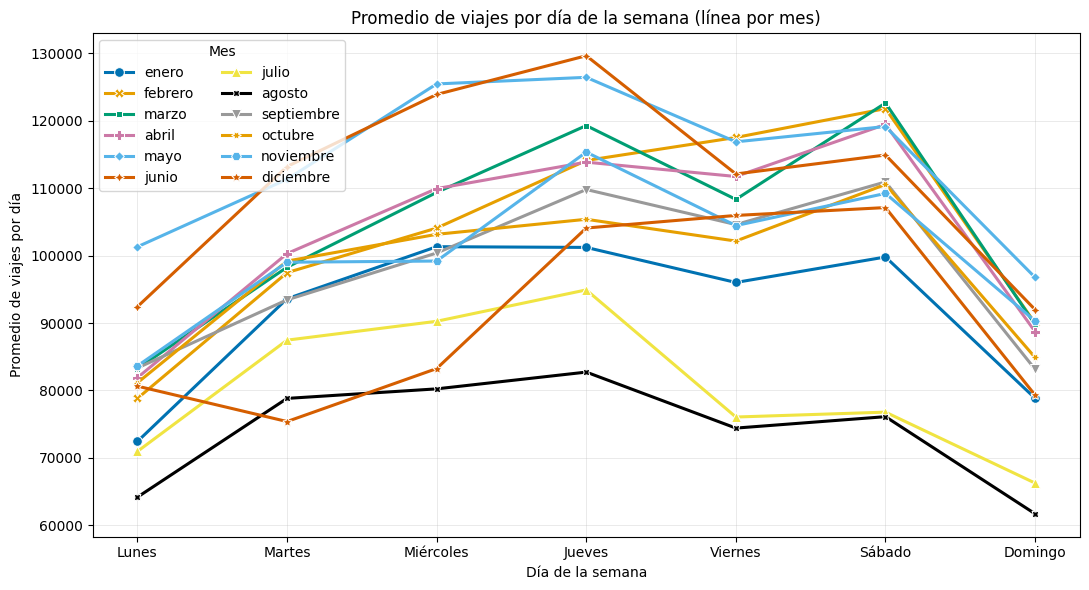

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Orden de días (en inglés si tu col está así) ---
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_orden_esp = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

# Meses que estás usando y sus nombres en español
orden_meses = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
nombres_meses = {
    1: "enero", 2: "febrero", 3: "marzo", 4: "abril", 5: "mayo", 6: "junio",
    7: "julio", 8: "agosto", 9: "septiembre", 10: "octubre", 11: "noviembre", 12: "diciembre"
}

# Paleta Okabe-Ito (apta para daltónicos): muy distinguible
palette_oi = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00', '#F0E442', '#000000', '#999999', '#E69F00', '#56B4E9', '#D55E00']

# --- Data prep: asegura orden de ejes y nombres de mes ---
promedio_semana = promedio_semana.copy()
promedio_semana = promedio_semana[promedio_semana['month'].isin(orden_meses)].copy()

promedio_semana['weekday'] = pd.Categorical(promedio_semana['weekday'], categories=dias_orden_esp, ordered=True)

# crea columna con nombre de mes (en español) y ordénala
promedio_semana['mes'] = promedio_semana['month'].map(nombres_meses)
promedio_semana['mes'] = pd.Categorical(
    promedio_semana['mes'],
    categories=[nombres_meses[m] for m in orden_meses],
    ordered=True
)

# --- Plot ---
plt.figure(figsize=(11,6))
sns.lineplot(
    data=promedio_semana.sort_values(['mes','weekday']),
    x='weekday', y='promedio_viajes',
    hue='mes', hue_order=[nombres_meses[m] for m in orden_meses],
    style='mes',  # estilos distintos por si se imprime en B/N
    markers=True, dashes=False, linewidth=2.2, markersize=7,
    palette=palette_oi
)

plt.title('Promedio de viajes por día de la semana (línea por mes)')
plt.xlabel('Día de la semana')
plt.ylabel('Promedio de viajes por día')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend(title='Mes', loc='upper left', ncol=2, frameon=True)
plt.tight_layout()
plt.show()

In [30]:
# Filtrar meses de interés
df_ene_may = df_all[df_all['month'].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])]
# Calcular viajes por día (unidad: fecha calendario)
viajes_por_dia = (
    df_ene_may.groupby(['month','date'])
    .size()
    .reset_index(name='count')
)
# Calcular promedio por mes
promedio_mes = (
    viajes_por_dia.groupby('month')['count']
    .mean()
    .reset_index(name='promedio_diario')
)
print(promedio_mes)

    month  promedio_diario
0       1     93025.896552
1       2    103615.480000
2       3    103850.129032
3       4    103796.133333
4       5    115012.533333
5       6    109224.862069
6       7     80154.866667
7       8     74392.645161
8       9     97438.724138
9      10     99083.333333
10     11    100756.444444
11     12     89182.562500


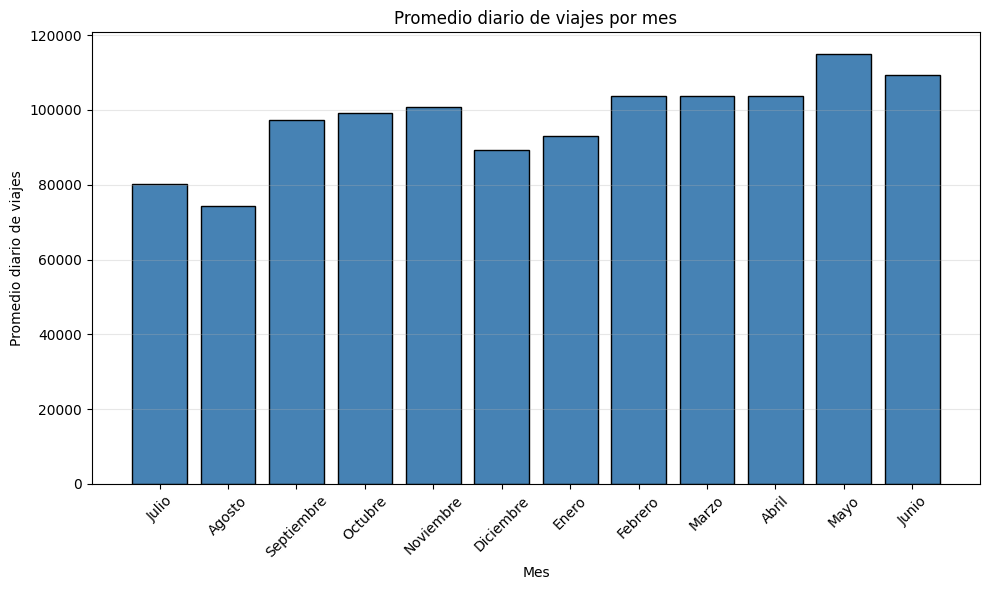

In [31]:
import matplotlib.pyplot as plt

# Diccionario de nombres de los meses
nombres_meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
    7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 
    11: "Noviembre", 12: "Diciembre"
}

# Orden personalizado: Jul(7)–Dic(12), luego Ene(1)–Jun(6)
orden_meses = [7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6]

# Reordenar el DataFrame según ese orden
promedio_mes["month"] = pd.Categorical(promedio_mes["month"], categories=orden_meses, ordered=True)
promedio_mes = promedio_mes.sort_values("month")

# Crear lista de etiquetas en español en el orden correcto
labels = [nombres_meses[m] for m in promedio_mes["month"]]

# Gráfico de barras
plt.figure(figsize=(10,6))
plt.bar(labels, promedio_mes["promedio_diario"], color="steelblue", edgecolor="black")

plt.title("Promedio diario de viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Promedio diario de viajes")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### **Conclusiones preliminares sobre la demanda**

1.	<u>Patrón semanal consistente</u>

La demanda presenta un comportamiento similar en todos los meses: aumenta progresivamente desde lunes, alcanza un pico entre miércoles y jueves, y disminuye hacia el fin de semana, con la menor demanda en domingo. El sábado vuelve a subir.

2.	<u>El mes no cambia el patrón semanal</u>

Aunque el nivel total de viajes puede variar entre meses, el patrón de lunes a domingo se mantiene estable. Es decir, el mes no altera la forma del comportamiento, solo la magnitud.

3.	<u>Importancia del día de la semana</u>

El día de la semana es un factor determinante en la variación de la demanda, mucho más relevante que el mes. Esto significa que el modelo de predicción debería tratar el día de la semana como variable clave.





---------------------------------
---------------------------------

<br>

#### **¿La semana dentro del mes cambia el patrón semanal?**

Es esperable que no sea un factor relevante.

¿Afecta la semana dentro del mes a los días con mayor o menor demanda?

In [32]:
import calendar

cal = calendar.Calendar(firstweekday=0)  # 0 = Monday

def week_of_month(dt):
    month_weeks = cal.monthdayscalendar(dt.year, dt.month)  # lista de semanas, c/semana = [L..D] (0 si no hay día)
    for i, week in enumerate(month_weeks, start=1):
        if dt.day in week:
            return i

In [33]:
df_all["week_of_month"] = df_all["pickup_datetime"].apply(week_of_month)

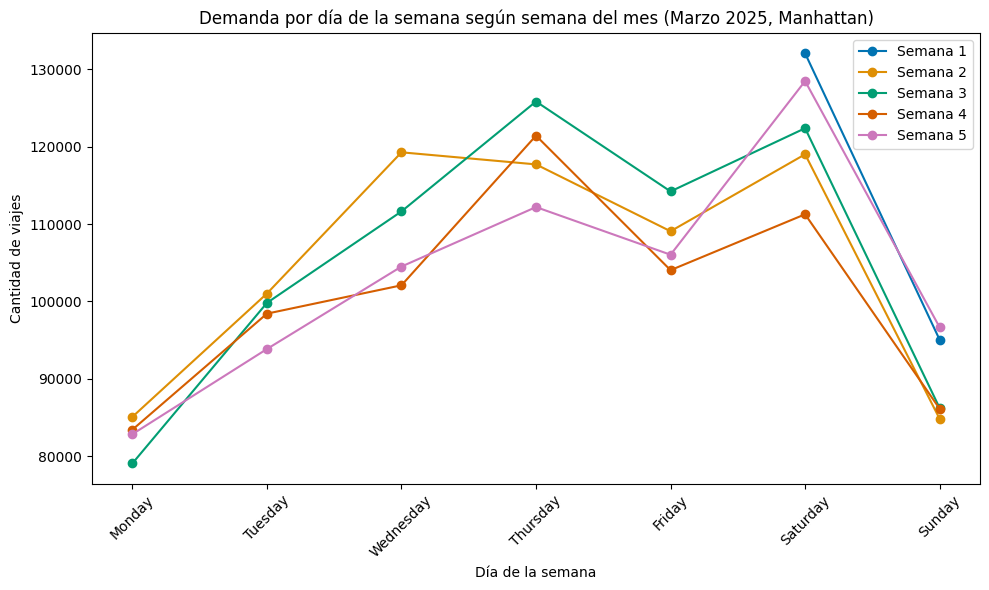

In [34]:
# Analizar si la semana dentro del mes afecta los días con mayor o menor demanda
mes_interes = 3
df_mes = df_all[df_all['month'] == mes_interes]
demanda_semana_dia = (
    df_mes.groupby(["week_of_month", "weekday"])
          .size()
          .reset_index(name="count")
)

# Ordenar los días de la semana
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Seleccionar solo semanas 1 a 4
semanas_validas = [1, 2, 3, 4, 5]
colores = sns.color_palette("colorblind", n_colors=len(semanas_validas))

plt.figure(figsize=(10,6))
for i, semana in enumerate(semanas_validas):
    datos_semana = demanda_semana_dia[demanda_semana_dia['week_of_month'] == semana]
    datos_semana = datos_semana.set_index('weekday').reindex(dias_orden)
    plt.plot(dias_orden, datos_semana['count'], marker='o',
         label=f'Semana {semana}', color=colores[i])
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de viajes')
plt.title('Demanda por día de la semana según semana del mes (Marzo 2025, Manhattan)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

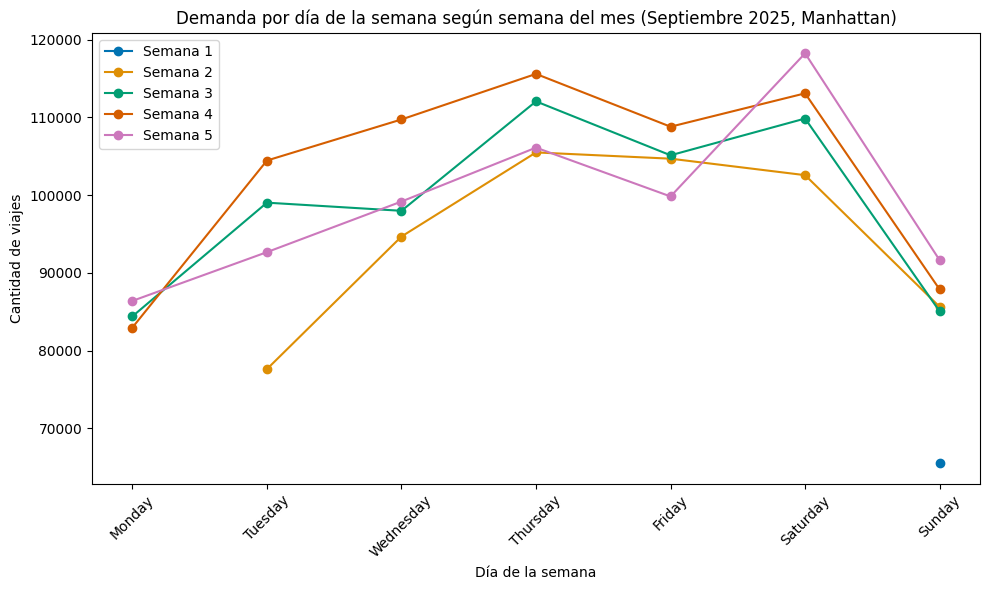

In [35]:
mes_interes = 9
df_mes = df_all[df_all['month'] == mes_interes]

# Agrupar por semana del mes y día de la semana
demanda_semana_dia = df_mes.groupby(['week_of_month', 'weekday']).size().reset_index(name='count')

# Ordenar los días de la semana
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Seleccionar solo semanas 1 a 4
semanas_validas = [1, 2, 3, 4, 5]
colores = sns.color_palette("colorblind", n_colors=len(semanas_validas))

plt.figure(figsize=(10,6))
for i, semana in enumerate(semanas_validas):
    datos_semana = demanda_semana_dia[demanda_semana_dia['week_of_month'] == semana]
    datos_semana = datos_semana.set_index('weekday').reindex(dias_orden)
    plt.plot(dias_orden, datos_semana['count'], marker='o', label=f'Semana {semana}', color=colores[i])
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de viajes')
plt.title('Demanda por día de la semana según semana del mes (Septiembre 2025, Manhattan)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El lunes es menro ya que es el día del trabajo y es feriado.

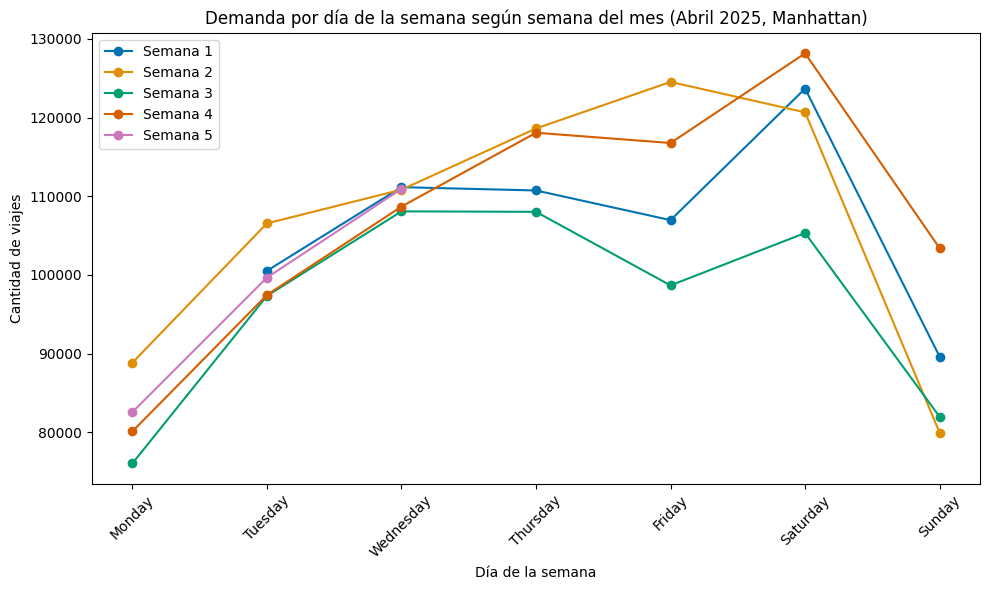

In [36]:
mes_interes = 4
df_mes = df_all[df_all['month'] == mes_interes]

# Agrupar por semana del mes y día de la semana
demanda_semana_dia = df_mes.groupby(['week_of_month', 'weekday']).size().reset_index(name='count')

# Ordenar los días de la semana
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Seleccionar solo semanas 1 a 4
semanas_validas = [1, 2, 3, 4, 5]
colores = sns.color_palette("colorblind", n_colors=len(semanas_validas))

plt.figure(figsize=(10,6))
for i, semana in enumerate(semanas_validas):
    datos_semana = demanda_semana_dia[demanda_semana_dia['week_of_month'] == semana]
    datos_semana = datos_semana.set_index('weekday').reindex(dias_orden)
    plt.plot(dias_orden, datos_semana['count'], marker='o', label=f'Semana {semana}', color=colores[i])
plt.xlabel('Día de la semana')
plt.ylabel('Cantidad de viajes')
plt.title('Demanda por día de la semana según semana del mes (Abril 2025, Manhattan)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Podemos ver como la semana no tiene practicamente ninguna influencia sobre el patrón semanal de demanda. La demanda para el viernes de la semana 3 no sube ya que es viernes santo.

Estabilidad entre semanas:
- La forma del patrón es casi igual en las 4 semanas
- La dda es predecible semana a semana

Variabilidad Moderada:
- Semana 4 llega a cerca de 2.000 el viernes, mientras que la 3 con apenas llega a 1.600
- El patrón se repite, pero hay diferencis de escala entre semanas
- Esto justifica usar distribuciones de probabilidad y no solo un promedio determinista por ejemplo

Patró laboral claro:
- De lunes a viernes la dda se mantiene alta
- Viernes tiende a ser el pico máximo
- Fines de semana caen fuertemente
- Mayor parte de los viajes tienen motivos laborales/diarios


-------------------------------------------------
-------------------------------------------------
<br><br>

#### **Dda según hora del día**
Esto logicamente debería afectar.

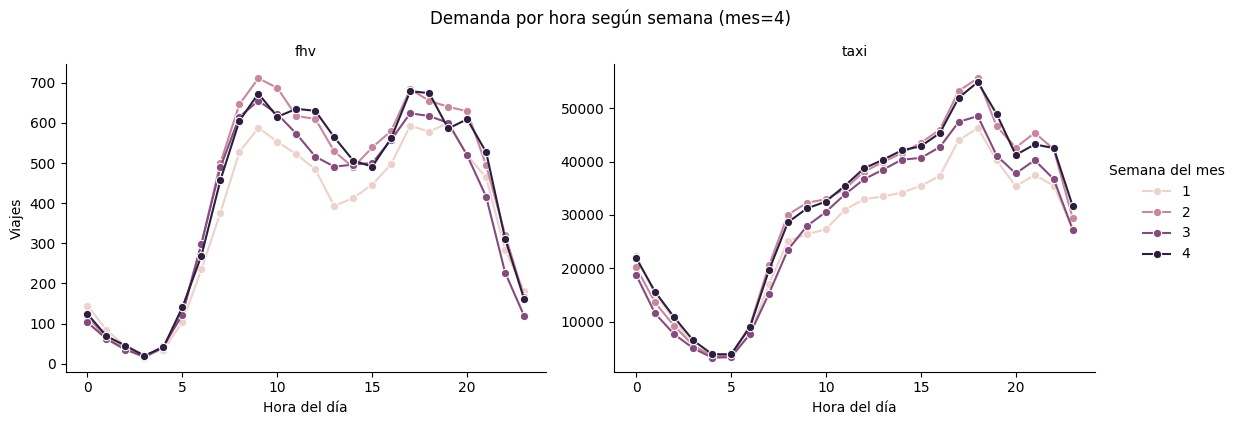

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar 'hour'
if 'hour' not in df_all.columns:
    df_all['hour'] = pd.to_datetime(df_all['pickup_datetime']).dt.hour

mes = 4  # p.ej., abril
tmp = df_all[df_all['month'] == mes].copy()

# Agregar: viajes por semana_del_mes × hora × tipo
g = (tmp
     .groupby(['tipo','week_of_month','hour'])
     .size().reset_index(name='count'))

# Plot: un panel por tipo
g = g[g['week_of_month'].isin([1,2,3,4])]
g = g.sort_values(['week_of_month','hour'])

g = sns.FacetGrid(g, col="tipo", sharey=False, height=4, aspect=1.4)
g.map_dataframe(sns.lineplot, x="hour", y="count", hue="week_of_month", marker="o")
g.add_legend(title="Semana del mes")
g.set_axis_labels("Hora del día", "Viajes")
g.set_titles(col_template="{col_name}")
plt.suptitle(f"Demanda por hora según semana ({mes=})", y=1.05)
plt.show()

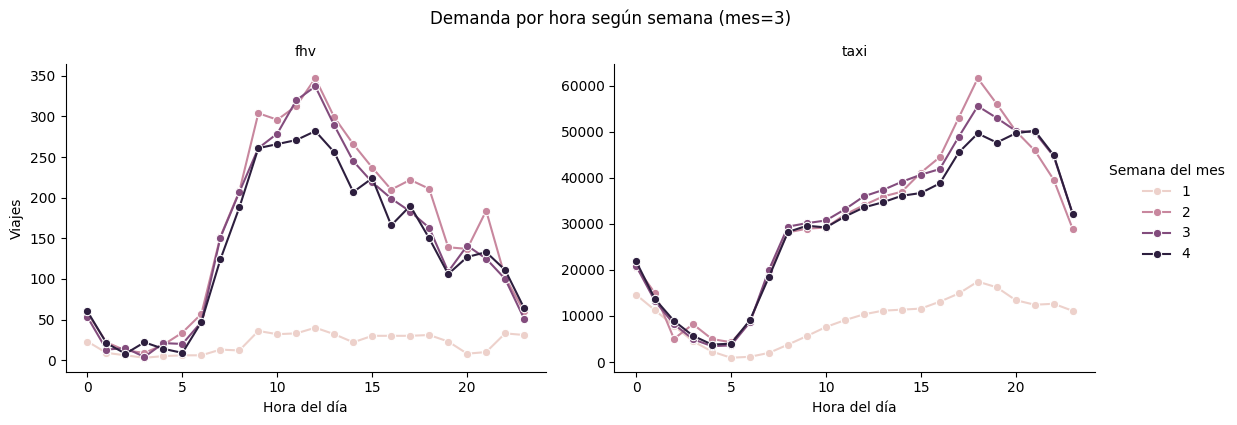

In [38]:
# Asegurar 'hour'
if 'hour' not in df_all.columns:
    df_all['hour'] = pd.to_datetime(df_all['pickup_datetime']).dt.hour

mes = 3
tmp = df_all[df_all['month'] == mes].copy()

# Agregar: viajes por semana_del_mes × hora × tipo
g = (tmp
     .groupby(['tipo','week_of_month','hour'])
     .size().reset_index(name='count'))

# Plot: un panel por tipo
g = g[g['week_of_month'].isin([1,2,3,4])]
g = g.sort_values(['week_of_month','hour'])

g = sns.FacetGrid(g, col="tipo", sharey=False, height=4, aspect=1.4)
g.map_dataframe(sns.lineplot, x="hour", y="count", hue="week_of_month", marker="o")
g.add_legend(title="Semana del mes")
g.set_axis_labels("Hora del día", "Viajes")
g.set_titles(col_template="{col_name}")
plt.suptitle(f"Demanda por hora según semana ({mes=})", y=1.05)
plt.show()

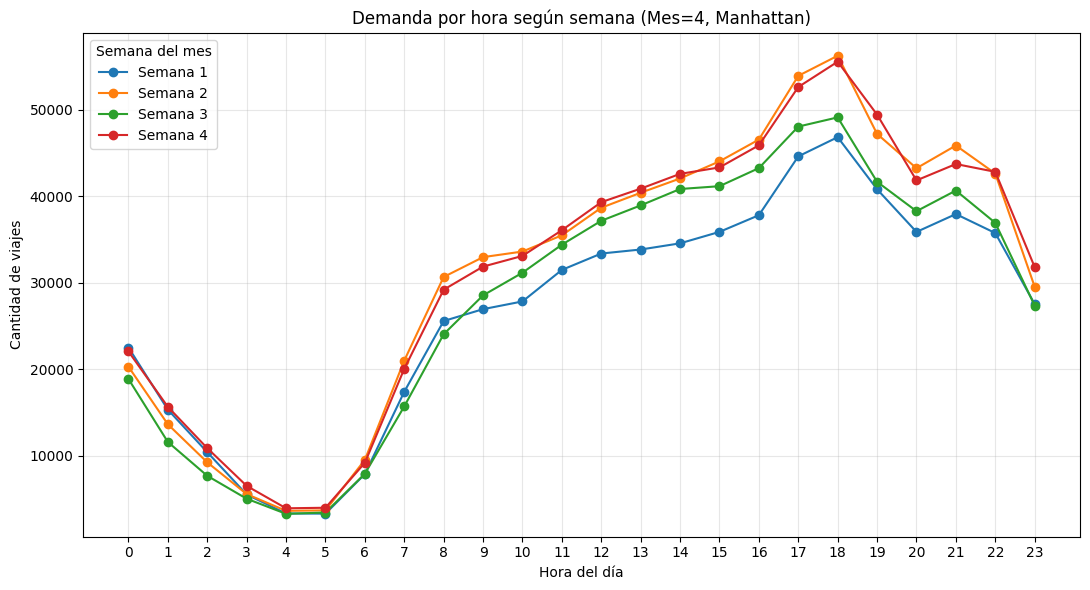

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar columna 'hour'
if 'hour' not in df_all.columns:
    df_all['hour'] = pd.to_datetime(df_all['pickup_datetime']).dt.hour

# Filtrar un mes específico
mes = 4  # abril
tmp = df_all[df_all['month'] == mes].copy()

# Agregar viajes por semana del mes × hora
g = (tmp
     .groupby(['week_of_month','hour'])
     .size().reset_index(name='count'))

# Solo semanas 1–4
g = g[g['week_of_month'].isin([1,2,3,4])]

plt.figure(figsize=(11,6))
for semana in sorted(g['week_of_month'].unique()):
    datos = g[g['week_of_month'] == semana]
    plt.plot(datos['hour'], datos['count'], marker='o', label=f'Semana {semana}')

plt.title(f"Demanda por hora según semana (Mes={mes}, Manhattan)")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de viajes")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend(title="Semana del mes")
plt.tight_layout()
plt.show()

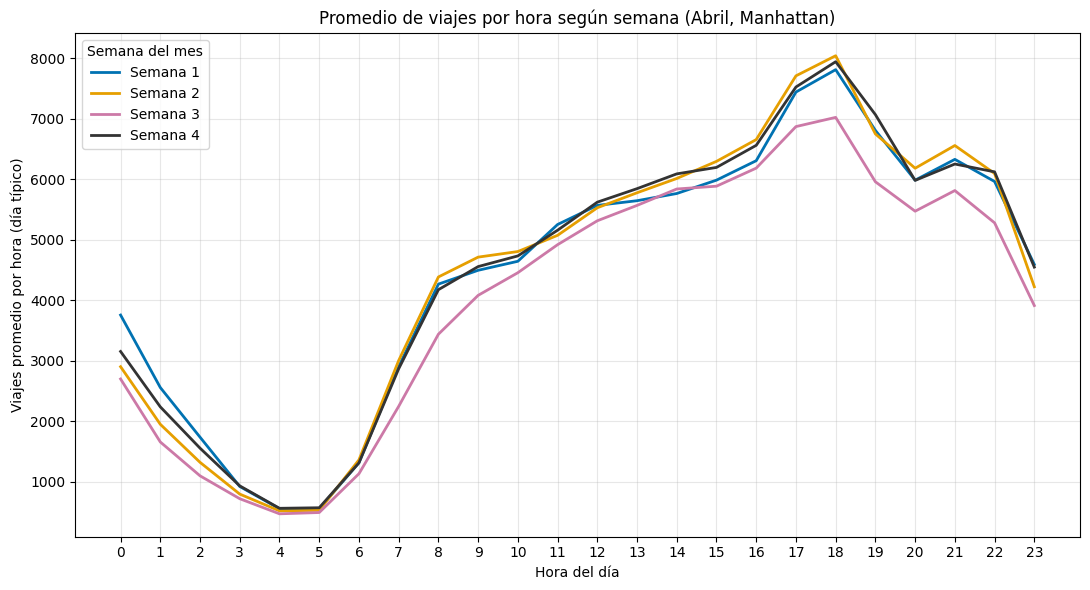

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar columna 'hour'
if 'hour' not in df_all.columns:
    df_all['hour'] = pd.to_datetime(df_all['pickup_datetime']).dt.hour
if 'date' not in df_all.columns:
    df_all['date'] = pd.to_datetime(df_all['pickup_datetime']).dt.date

# Filtrar un mes específico
mes = 4  # abril
tmp = df_all[df_all['month'] == mes].copy()

# Agregar viajes por semana del mes × hora × día
g = (tmp.groupby(['week_of_month','date','hour'])
       .size()
       .reset_index(name='count'))

# Promedio por semana × hora
promedio = (g.groupby(['week_of_month','hour'])['count']
              .mean()
              .reset_index(name='promedio_diario'))

# Solo semanas 1–4
promedio = promedio[promedio['week_of_month'].isin([1,2,3,4])]

colores = ["#0072B2", "#E69F00", "#CC79A7", "#333333"]

plt.figure(figsize=(11,6))
for i, semana in enumerate(sorted(promedio['week_of_month'].unique())):
    datos = promedio[promedio['week_of_month'] == semana]
    plt.plot(datos['hour'], datos['promedio_diario'], 
             label=f'Semana {semana}', linewidth=2,
             color=colores[i])

plt.title("Promedio de viajes por hora según semana (Abril, Manhattan)")
plt.xlabel("Hora del día")
plt.ylabel("Viajes promedio por hora (día típico)")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.legend(title="Semana del mes")
plt.tight_layout()
plt.show()

La forma de la curva es consistente semana a semana

Claramente se puede observar en ambos gráficos un patrón por hora del día, en donde la dda tiene picos muy definidos. El primer pico fuerte es en la mañana y el segundo pico en la tarde noche.

El patrón es muy estable entre meses y entre las semanas del mes. 

La semana dentro del mes no agrega valor, por lo que se podía ignorar.

El mes no cambia la forma del patrón por día de semana ni tampoco por hora, pero si altera en algunos casos un poco la magnitud total de viajes. Por lo tanto, habría que ver si hay un patrón con lo que pasa con los meses, y si lo hay podríamos considerar un factor de escala.

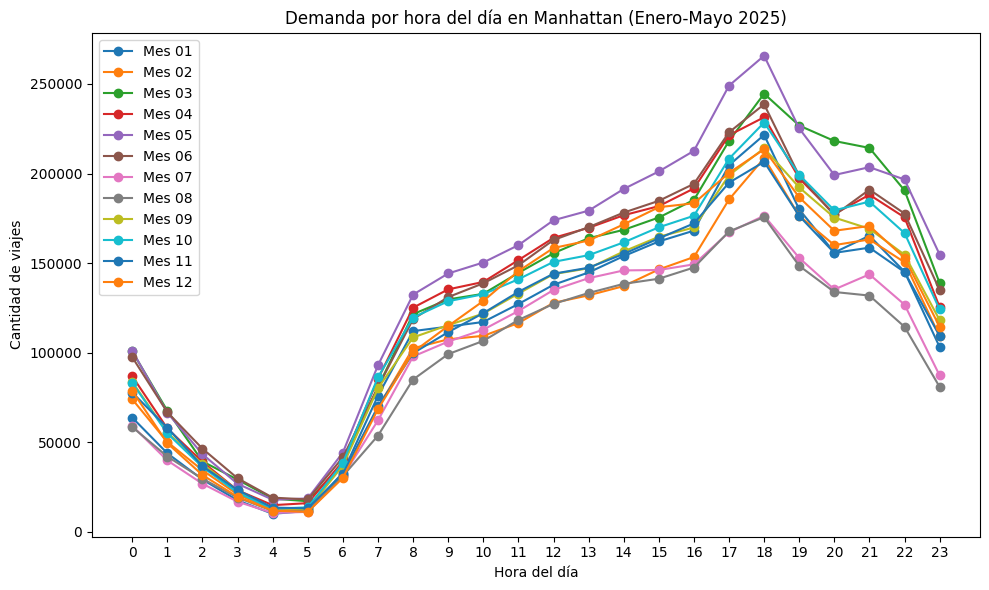

In [41]:
# Agrupar por mes y hora
demanda_hora = df_all.groupby(['month', 'hour']).size().reset_index(name='count')

# Graficar
plt.figure(figsize=(10,6))
for mes in sorted(demanda_hora['month'].unique()):
    datos_mes = demanda_hora[demanda_hora['month'] == mes]
    plt.plot(datos_mes['hour'], datos_mes['count'], marker='o', label=f'Mes {mes:02d}')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de viajes')
plt.title('Demanda por hora del día en Manhattan (Enero-Mayo 2025)')
plt.legend()
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

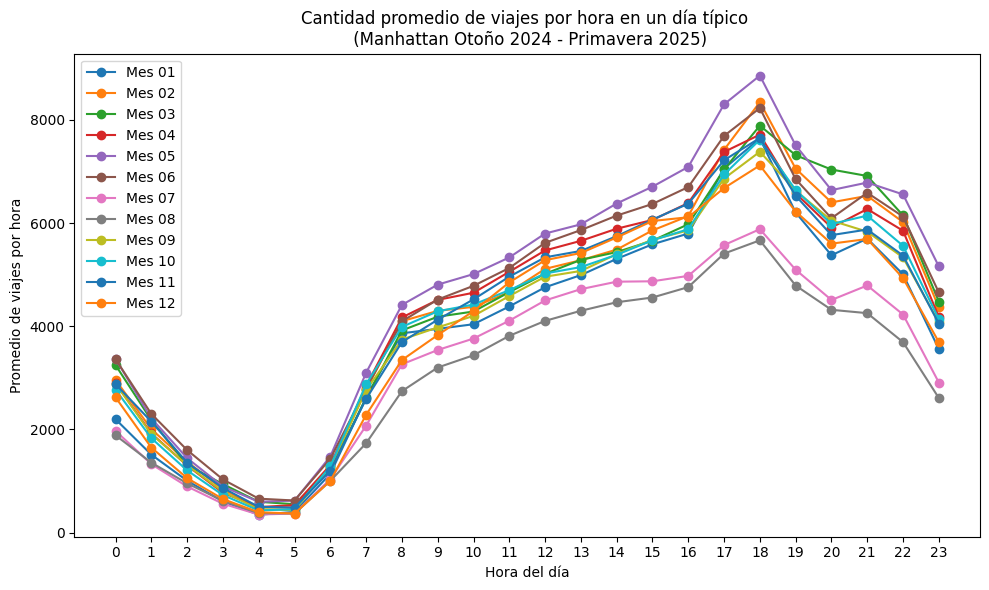

In [42]:
# Asegurar que pickup_datetime es datetime
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['date'] = df_all['pickup_datetime'].dt.date
df_all['hour'] = df_all['pickup_datetime'].dt.hour

# 1) Agrupar por fecha y hora → cuántos viajes hubo ese día-hora
viajes_dia_hora = df_all.groupby(['date','month','hour']).size().reset_index(name='count')

# 2) Promediar por mes y hora
promedio_hora = viajes_dia_hora.groupby(['month','hour'])['count'].mean().reset_index()

# Graficar
plt.figure(figsize=(10,6))
for mes in sorted(promedio_hora['month'].unique()):
    datos_mes = promedio_hora[promedio_hora['month'] == mes]
    plt.plot(datos_mes['hour'], datos_mes['count'], marker='o', label=f'Mes {mes:02d}')
plt.xlabel('Hora del día')
plt.ylabel('Promedio de viajes por hora')
plt.title('Cantidad promedio de viajes por hora en un día típico \n (Manhattan Otoño 2024 - Primavera 2025)')
plt.legend()
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

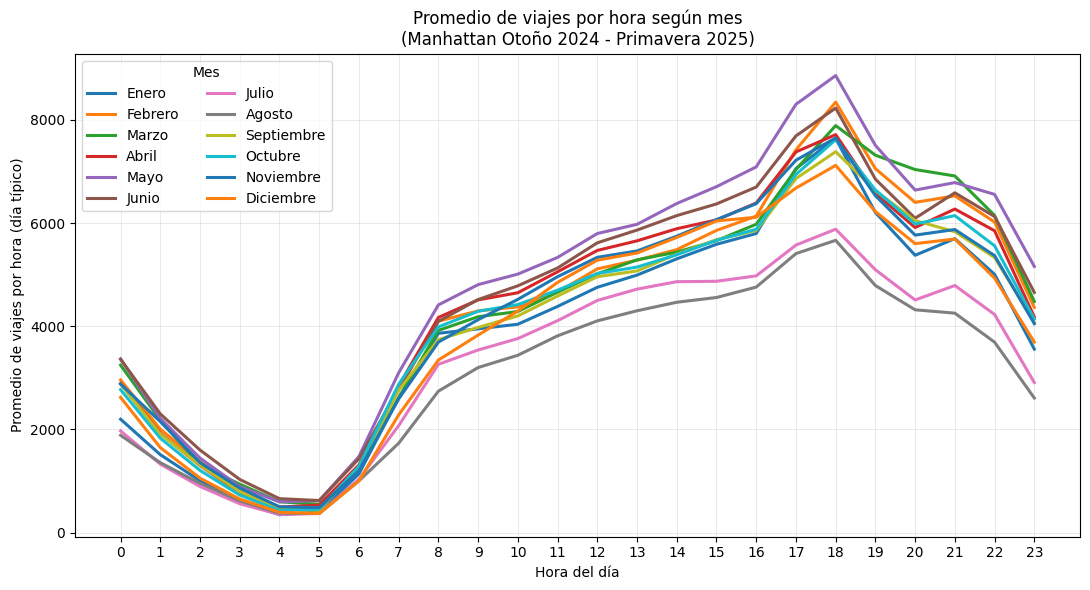

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Diccionario meses ---
nombres_meses = {
    1: "enero", 2: "febrero", 3: "marzo", 4: "abril", 5: "mayo", 6: "junio",
    7: "julio", 8: "agosto", 9: "septiembre", 10: "octubre", 11: "noviembre", 12: "diciembre"
}
orden_meses = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# --- Asegurar columnas ---
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['date'] = df_all['pickup_datetime'].dt.date
df_all['hour'] = df_all['pickup_datetime'].dt.hour

# --- 1) Agrupar viajes por fecha-hora ---
viajes_dia_hora = (
    df_all.groupby(['date','month','hour'])
    .size().reset_index(name='count')
)

# --- 2) Promedio por mes-hora ---
promedio_hora = (
    viajes_dia_hora.groupby(['month','hour'])['count']
    .mean().reset_index()
)

# --- 3) Añadir nombre del mes en español ---
promedio_hora['mes'] = promedio_hora['month'].map(nombres_meses)
promedio_hora['mes'] = pd.Categorical(
    promedio_hora['mes'],
    categories=[nombres_meses[m] for m in orden_meses],
    ordered=True
)

# --- 4) Plot ---
plt.figure(figsize=(11,6))
for i, mes in enumerate(orden_meses):
    datos_mes = promedio_hora[promedio_hora['month'] == mes]
    plt.plot(datos_mes['hour'], datos_mes['count'],
             label=nombres_meses[mes].capitalize(), 
             linewidth=2.2)

plt.xlabel('Hora del día')
plt.ylabel('Promedio de viajes por hora (día típico)')
plt.title('Promedio de viajes por hora según mes\n(Manhattan Otoño 2024 - Primavera 2025)')
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend(title='Mes', ncol=2, frameon=True)
plt.tight_layout()
plt.show()

------------------------------------
------------------------------------

Miremos un poco los pares OD

/var/folders/8d/l8gb32fj0t9792hbywcsbd9w0000gn/T/ipykernel_48643/4030993001.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


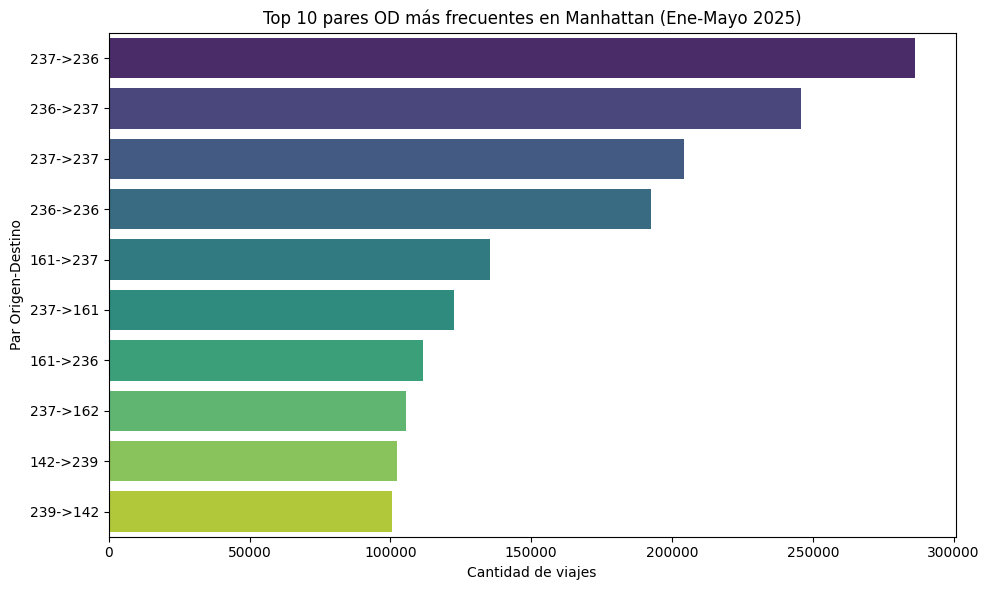

In [44]:
# Top 10 OD en Manhattan
top_od = (
    df_all.groupby(['PUlocationID', 'DOlocationID'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_od,
    x='count',
    y=top_od.apply(lambda x: f"{int(x['PUlocationID'])}->{int(x['DOlocationID'])}", axis=1),
    palette="viridis"
)
plt.xlabel("Cantidad de viajes")
plt.ylabel("Par Origen-Destino")
plt.title("Top 10 pares OD más frecuentes en Manhattan (Ene-Mayo 2025)")
plt.tight_layout()
plt.show()

/var/folders/8d/l8gb32fj0t9792hbywcsbd9w0000gn/T/ipykernel_48643/2100789683.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


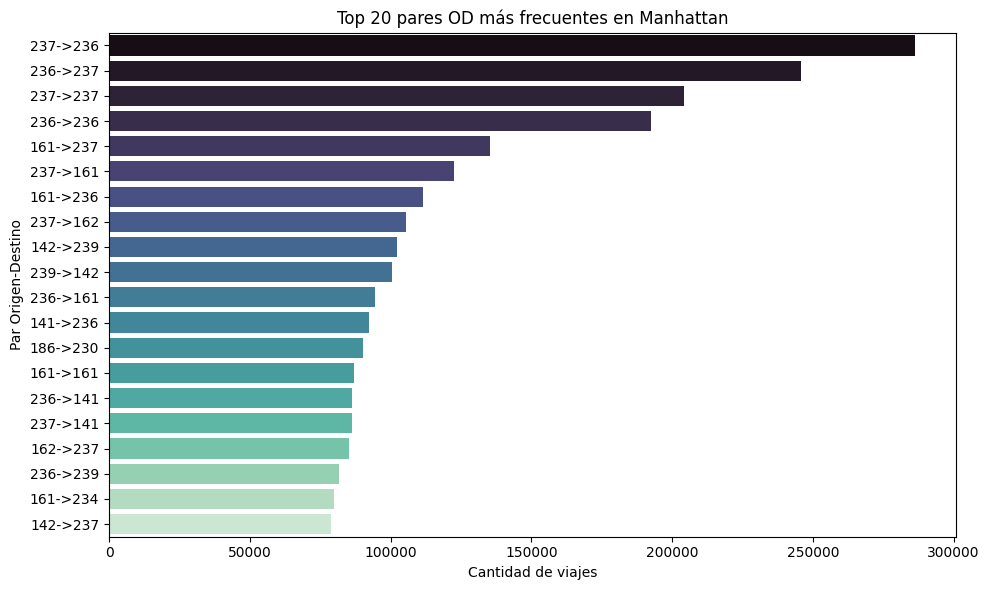

In [45]:
# Top 20 OD
top_od = (
    df_all.groupby(['PUlocationID', 'DOlocationID'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
    .head(20)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_od,
    x='count',
    y=top_od.apply(lambda x: f"{int(x['PUlocationID'])}->{int(x['DOlocationID'])}", axis=1),
    palette="mako"
)
plt.xlabel("Cantidad de viajes")
plt.ylabel("Par Origen-Destino")
plt.title("Top 20 pares OD más frecuentes en Manhattan")
plt.tight_layout()
plt.show()

/var/folders/8d/l8gb32fj0t9792hbywcsbd9w0000gn/T/ipykernel_48643/1250444305.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


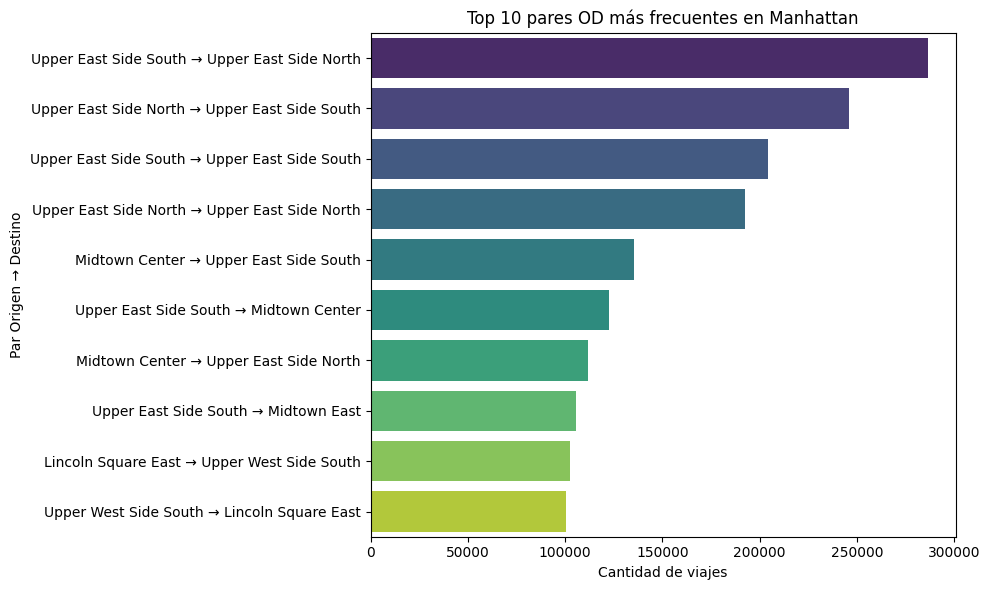

,PU_zone,DO_zone,count
3562,Upper East Side South,Upper East Side North,286378
3499,Upper East Side North,Upper East Side South,245763
3563,Upper East Side South,Upper East Side South,204222
3498,Upper East Side North,Upper East Side North,192381
2413,Midtown Center,Upper East Side South,135407
3545,Upper East Side South,Midtown Center,122607
2412,Midtown Center,Upper East Side North,111693
3546,Upper East Side South,Midtown East,105640
1906,Lincoln Square East,Upper West Side South,102299
3601,Upper West Side South,Lincoln Square East,100442


In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeo de IDs a nombres de zona
zonas = pd.read_csv("Datos/taxi_zones/taxi_zone_lookup.csv")
zonas["LocationID"] = pd.to_numeric(zonas["LocationID"], errors="coerce").astype("Int64")

id2zone = dict(zip(zonas["LocationID"], zonas["Zone"]))

# Asegurar que PUlocationID y DOlocationID sean enteros (no floats con NaN)
for col in ["PUlocationID", "DOlocationID"]:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce").astype("Int64")

# Crear columnas con nombres
df_all["PU_zone"] = df_all["PUlocationID"].map(id2zone)
df_all["DO_zone"] = df_all["DOlocationID"].map(id2zone)

# Top 10 pares OD
top10_od = (
    df_all.groupby(["PU_zone", "DO_zone"])
          .size().reset_index(name="count")
          .sort_values("count", ascending=False)
          .head(10)
)

# Gráfico
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_od,
    x="count",
    y=top10_od["PU_zone"] + " → " + top10_od["DO_zone"],
    palette="viridis"
)
plt.xlabel("Cantidad de viajes")
plt.ylabel("Par Origen → Destino")
plt.title("Top 10 pares OD más frecuentes en Manhattan")
plt.tight_layout()
plt.show()

# Mostrar tabla
top10_od

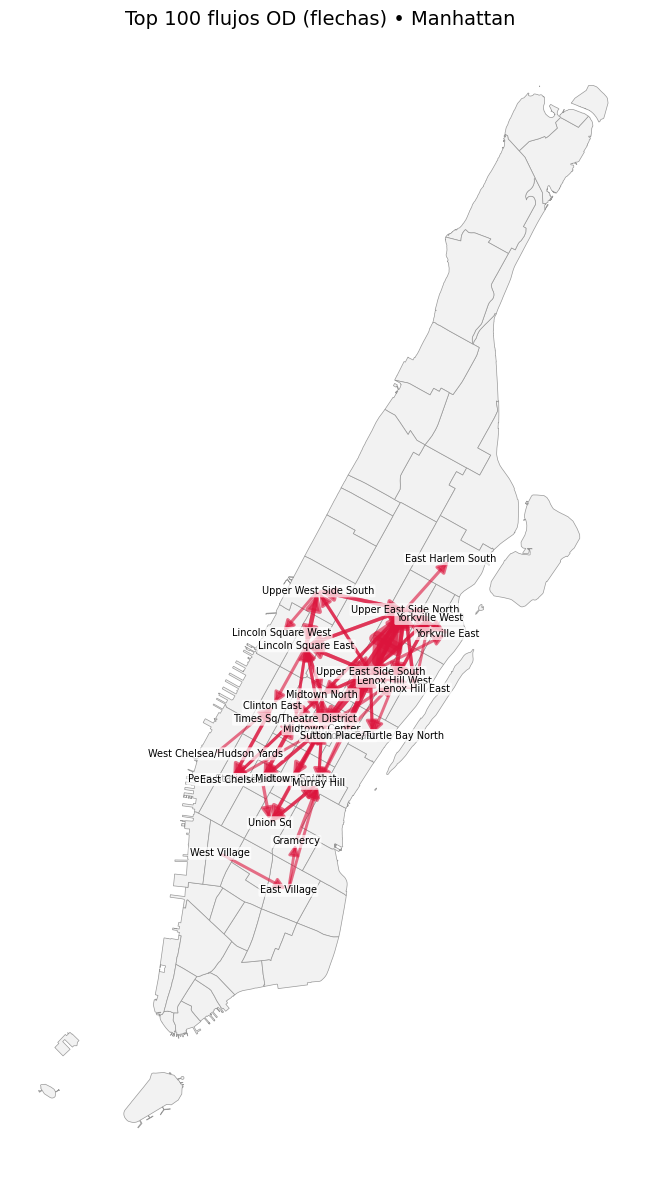

In [47]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

shp_path = "Datos/taxi_zones/taxi_zones.shp"
lookup_path = "Datos/taxi_zones/taxi_zone_lookup.csv"
gdf = gpd.read_file(shp_path)

lookup = pd.read_csv(lookup_path)
lookup["LocationID"] = pd.to_numeric(lookup["LocationID"], errors="coerce").astype("Int64")

gdf = gdf.merge(lookup[["LocationID","Borough","Zone"]], on="LocationID", how="left")
gdf_m = gdf[gdf["Borough"].str.lower().eq("manhattan")]

# --- 2) Top 10 OD (usa tu df_all ya filtrado a Manhattan) ---
# Asegurar tipos
for col in ["PUlocationID","DOlocationID"]:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce").astype("Int64")

top_od = (df_all
          .groupby(["PUlocationID","DOlocationID"])
          .size().reset_index(name="count")
          .sort_values("count", ascending=False)
          .head(100))

# --- 3) Centroides de cada zona (para dibujar las flechas) ---
centroids = gdf.set_index("LocationID").geometry.centroid

# --- 4) Plot base: mapa de Manhattan ---
fig, ax = plt.subplots(figsize=(10,12))
gdf_m.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#999999", linewidth=0.5)

# --- 5) Dibujar flechas para cada OD del Top 10 ---
cmax = top_od["count"].max()

for _, row in top_od.iterrows():
    pu = row["PUlocationID"]
    do = row["DOlocationID"]
    n  = row["count"]

    # coordenadas (x,y) de origen y destino
    try:
        p = centroids.loc[pu]
        d = centroids.loc[do]
    except KeyError:
        continue  # por si algún ID no existe en el shapefile

    # escala de grosor/tamaño según cantidad
    w = 1.0 + 6.0*(n/cmax)         # ancho de línea
    m = 8.0 + 40.0*(n/cmax)        # tamaño de la punta

    arrow = FancyArrowPatch(
        (p.x, p.y), (d.x, d.y),
        arrowstyle='-|>', mutation_scale=m,
        linewidth=w, color="crimson", alpha=0.6
    )
    ax.add_patch(arrow)

# (Opcional) etiquetar los nodos más usados en el Top 10
id2name = dict(zip(lookup["LocationID"], lookup["Zone"]))
used_nodes = pd.unique(top_od[["PUlocationID","DOlocationID"]].values.ravel("K"))
for lid in used_nodes:
    if pd.isna(lid) or lid not in centroids.index: 
        continue
    c = centroids.loc[lid]
    name = id2name.get(lid, str(lid))
    ax.text(c.x, c.y, name, fontsize=7, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

ax.set_title("Top 100 flujos OD (flechas) • Manhattan ", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

/var/folders/8d/l8gb32fj0t9792hbywcsbd9w0000gn/T/ipykernel_48643/4080268185.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")   # puedes probar "magma", "plasma", etc.


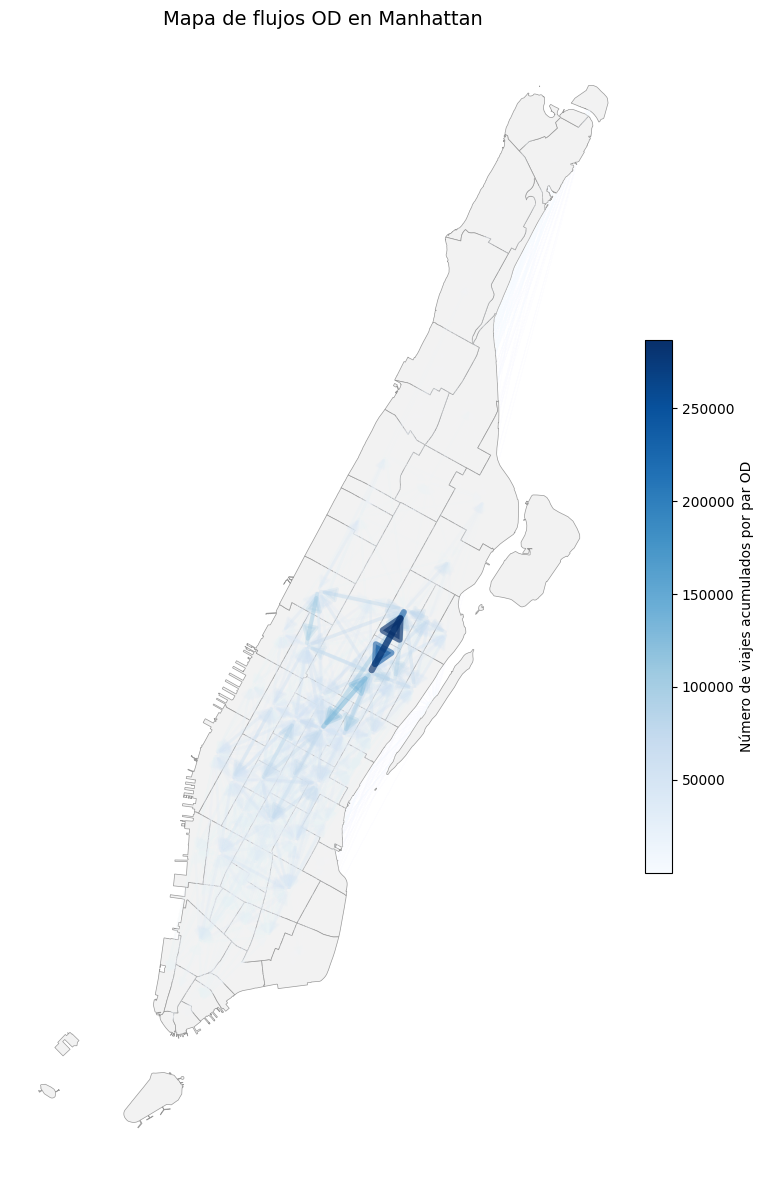

In [48]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np

# -------------------- Insumos geográficos --------------------
shp_path    = "Datos/taxi_zones/taxi_zones.shp"
lookup_path = "Datos/taxi_zones/taxi_zone_lookup.csv"

gdf = gpd.read_file(shp_path)
lk  = pd.read_csv(lookup_path)
lk["LocationID"] = pd.to_numeric(lk["LocationID"], errors="coerce").astype("Int64")

# Unimos info
gdf = gdf.merge(lk[["LocationID","Borough","Zone"]], on="LocationID", how="left")
gdf_m = gdf[gdf["Borough"].str.lower().eq("manhattan")]

# Centroides
centroids = gdf.set_index("LocationID").geometry.centroid

# -------------------- Filtrar solo Manhattan -----------------
df_m = df_all[
    df_all["PUlocationID"].isin(gdf_m["LocationID"]) & 
    df_all["DOlocationID"].isin(gdf_m["LocationID"])
].copy()

# -------------------- Flujos OD (TODOS) ----------------------
flows = (
    df_m.groupby(["PUlocationID","DOlocationID"])
         .size().reset_index(name="count")
         .sort_values("count", ascending=False)
)

# -------------------- Plot base: mapa de Manhattan -----------
fig, ax = plt.subplots(figsize=(10,12))
gdf_m.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#999999", linewidth=0.5)

# Escala
cmax = flows["count"].max()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib import cm, colors

# Ordena de menor a mayor para pintar arriba los grandes
flows_sorted = flows.sort_values("count", ascending=True).reset_index(drop=True)

# Normalización y colormap
norm = colors.Normalize(vmin=flows_sorted["count"].min(), vmax=flows_sorted["count"].max())
cmap = cm.get_cmap("Blues")   # puedes probar "magma", "plasma", etc.

for _, row in flows_sorted.iterrows():
    pu, do, n = row["PUlocationID"], row["DOlocationID"], row["count"]
    if (pu not in centroids.index) or (do not in centroids.index):
        continue
    p, d = centroids.loc[pu], centroids.loc[do]

    s = norm(n)                          # 0..1 según demanda
    color = cmap(s)                      # color más intenso si s es alto
    lw = 0.2 + 4.5*np.sqrt(s)            # grosor suavizado
    alpha = 0.08 + 0.55*s                # opacidad: baja para flujos chicos

    arrow = FancyArrowPatch(
        (p.x, p.y), (d.x, d.y),
        arrowstyle="-|>", mutation_scale=6 + 28*np.sqrt(s),
        linewidth=lw, color=color, alpha=alpha, zorder=2 + 2*s
    )
    ax.add_patch(arrow)

# opcional: barra de color para interpretar intensidades
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.030, pad=0.01)
cbar.set_label("Número de viajes acumulados por par OD")

ax.set_title("Mapa de flujos OD en Manhattan", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

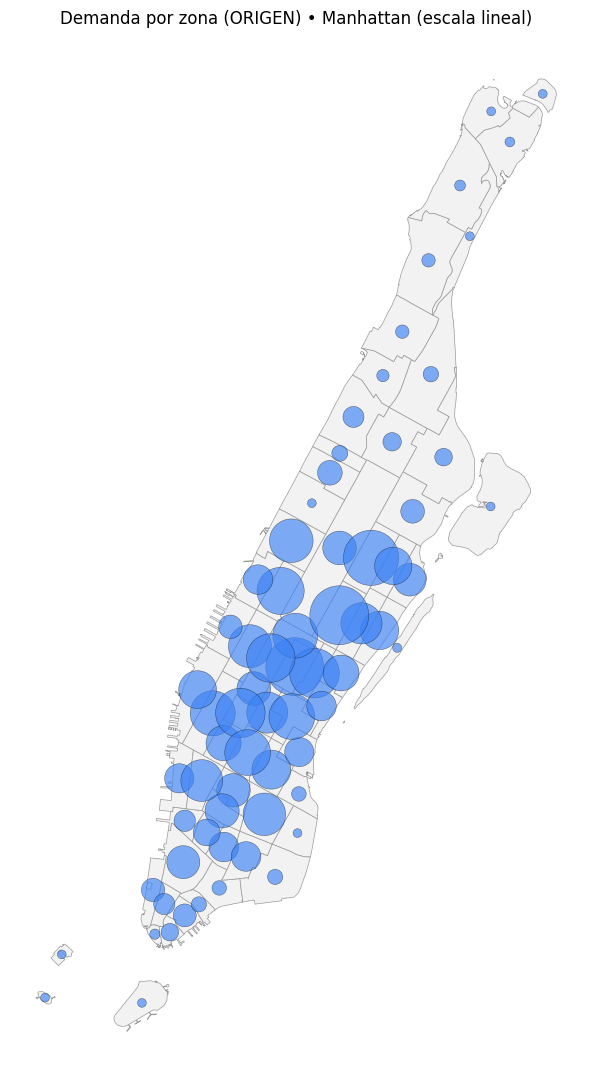

In [49]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ---------- 1) Geo ----------
shp_path    = "Datos/taxi_zones/taxi_zones.shp"
lookup_path = "Datos/taxi_zones/taxi_zone_lookup.csv"

gdf = gpd.read_file(shp_path)
lk  = pd.read_csv(lookup_path)
lk["LocationID"] = pd.to_numeric(lk["LocationID"], errors="coerce").astype("Int64")

gdf = gdf.merge(lk[["LocationID","Borough","Zone"]], on="LocationID", how="left")
gdf_m = gdf[gdf["Borough"].str.lower().eq("manhattan")].copy()

# Centroides para ubicar puntos
cent = gdf_m.copy()
cent["cx"] = cent.geometry.centroid.x
cent["cy"] = cent.geometry.centroid.y

# ---------- 2) Demanda por ORIGEN ----------
for c in ["PUlocationID","DOlocationID"]:
    df_all[c] = pd.to_numeric(df_all[c], errors="coerce").astype("Int64")

pu_counts = (df_all[df_all["PUlocationID"].isin(cent["LocationID"])]
             .groupby("PUlocationID").size().rename("pu_count").reset_index())

# Une conteos a centroides
cent = cent.merge(pu_counts, left_on="LocationID", right_on="PUlocationID", how="left")
cent["pu_count"] = cent["pu_count"].fillna(0)

# ---------- 3) Escala lineal (sin log) ----------
def scale_linear(x, min_size=40, max_size=1600):
    x = x.astype(float)
    xmin, xmax = x.min(), x.max()
    if xmax == xmin:
        return np.full_like(x, (min_size+max_size)/2.0)
    return min_size + (x - xmin) * (max_size - min_size) / (xmax - xmin)

sizes = scale_linear(cent["pu_count"], min_size=40, max_size=1800)

# ---------- 4) Plot ----------
plt.figure(figsize=(8,11))
ax = plt.gca()
gdf_m.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#9a9a9a", linewidth=0.5, zorder=1)
plt.scatter(cent["cx"], cent["cy"], s=sizes, color="#3b82f6", alpha=0.65,
            edgecolor="k", linewidth=0.3, zorder=2)
plt.title("Demanda por zona (ORIGEN) • Manhattan (escala lineal)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [50]:
# Contar viajes por zona origen
viajes_origen = df_all.groupby('PUlocationID').size().reset_index(name='count')

# Ordenar de mayor a menor
viajes_origen = viajes_origen.sort_values('count', ascending=False)

In [51]:
total_viajes = viajes_origen['count'].sum()
top3_viajes = viajes_origen.head(3)['count'].sum()

In [52]:
top3_pct = (top3_viajes / total_viajes) * 100
print(f"Las top 3 zonas concentran el {top3_pct:.2f}% de los viajes")

Las top 3 zonas concentran el 15.54% de los viajes


In [53]:
df_all = df_all[df_all['PUlocationID'].isin(manhattan_ids)]

----------------------------------------------
----------------------------------------------

Curvas promedio por hora, separada por día de la semana

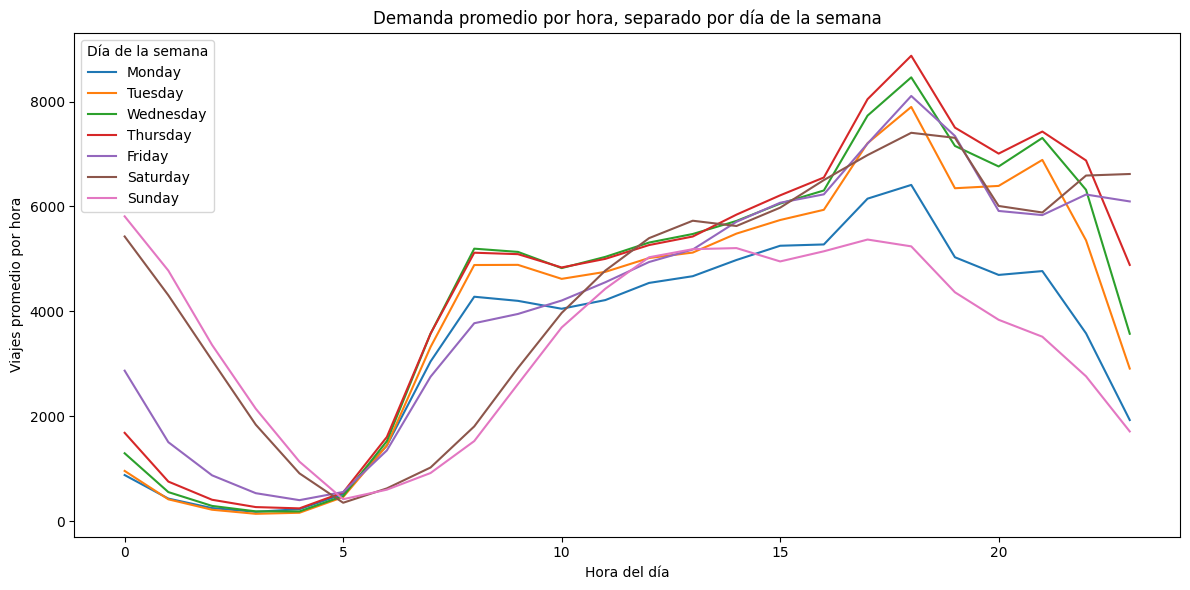

In [54]:
# contar viajes por fecha-hora
df_all['date'] = df_all['pickup_datetime'].dt.date
viajes_hora = df_all.groupby(['date','weekday','hour']).size().reset_index(name='count')

# promedio por hora y weekday
promedio = viajes_hora.groupby(['weekday','hour'])['count'].mean().reset_index()

# ordenar días
dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
promedio['weekday'] = pd.Categorical(promedio['weekday'], categories=dias, ordered=True)

plt.figure(figsize=(12,6))
sns.lineplot(data=promedio, x='hour', y='count', hue='weekday')
plt.title("Demanda promedio por hora, separado por día de la semana")
plt.xlabel("Hora del día"); plt.ylabel("Viajes promedio por hora")
# Leyenda fija en la esquina superior izquierda
plt.legend(
    title="Día de la semana",
    loc="upper left",   # <- misma posición siempre
    frameon=True)
plt.tight_layout()
plt.show()

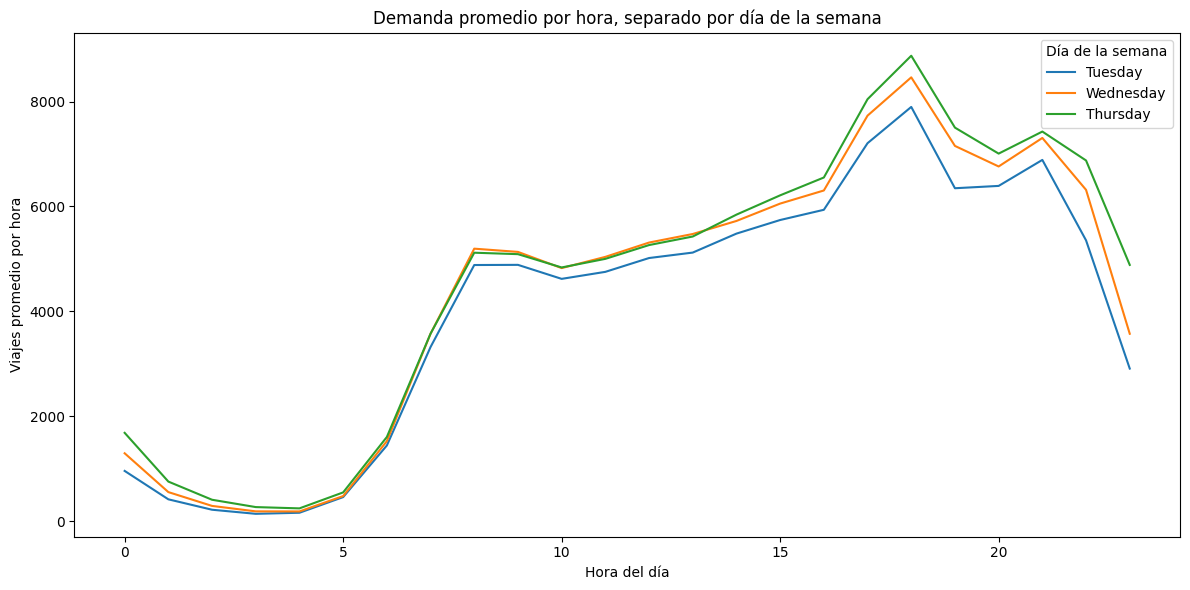

In [55]:
# contar viajes por fecha-hora
df_all['date'] = df_all['pickup_datetime'].dt.date
viajes_hora = df_all.groupby(['date','weekday','hour']).size().reset_index(name='count')

# promedio por hora y weekday
promedio = viajes_hora.groupby(['weekday','hour'])['count'].mean().reset_index()

# Solo consideremos los martes, miércoles y jueves
promedio = promedio[promedio['weekday'].isin(['Tuesday', 'Wednesday', 'Thursday'])]

# ordenar días
dias = ['Tuesday','Wednesday','Thursday']
promedio['weekday'] = pd.Categorical(promedio['weekday'], categories=dias, ordered=True)

plt.figure(figsize=(12,6))
sns.lineplot(data=promedio, x='hour', y='count', hue='weekday')
plt.title("Demanda promedio por hora, separado por día de la semana")
plt.xlabel("Hora del día"); plt.ylabel("Viajes promedio por hora")
plt.legend(title="Día de la semana")
plt.tight_layout()
plt.show()

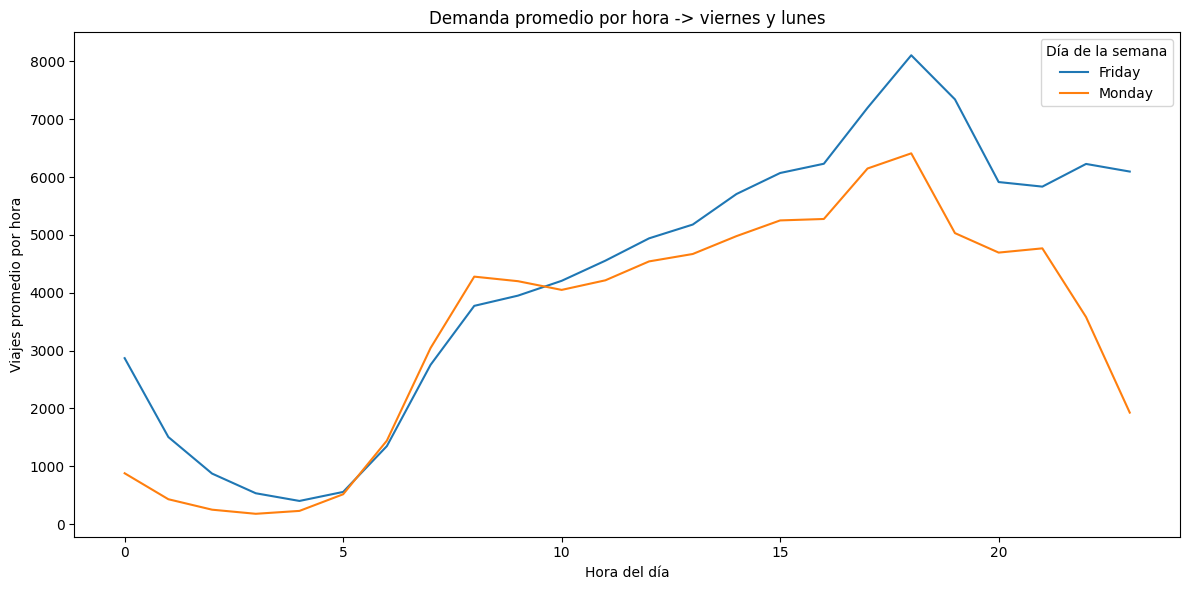

In [56]:
# contar viajes por fecha-hora
df_all['date'] = df_all['pickup_datetime'].dt.date
viajes_hora = df_all.groupby(['date','weekday','hour']).size().reset_index(name='count')

# promedio por hora y weekday
promedio = viajes_hora.groupby(['weekday','hour'])['count'].mean().reset_index()

# Solo consideremos los martes, miércoles y jueves
promedio = promedio[promedio['weekday'].isin(['Friday','Monday'])]

# ordenar días
dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
#promedio['weekday'] = pd.Categorical(promedio['weekday'], categories=dias, ordered=True)

plt.figure(figsize=(12,6))
sns.lineplot(data=promedio, x='hour', y='count', hue='weekday')
plt.title("Demanda promedio por hora -> viernes y lunes")
plt.xlabel("Hora del día"); plt.ylabel("Viajes promedio por hora")
plt.legend(title="Día de la semana")
plt.tight_layout()
plt.show()

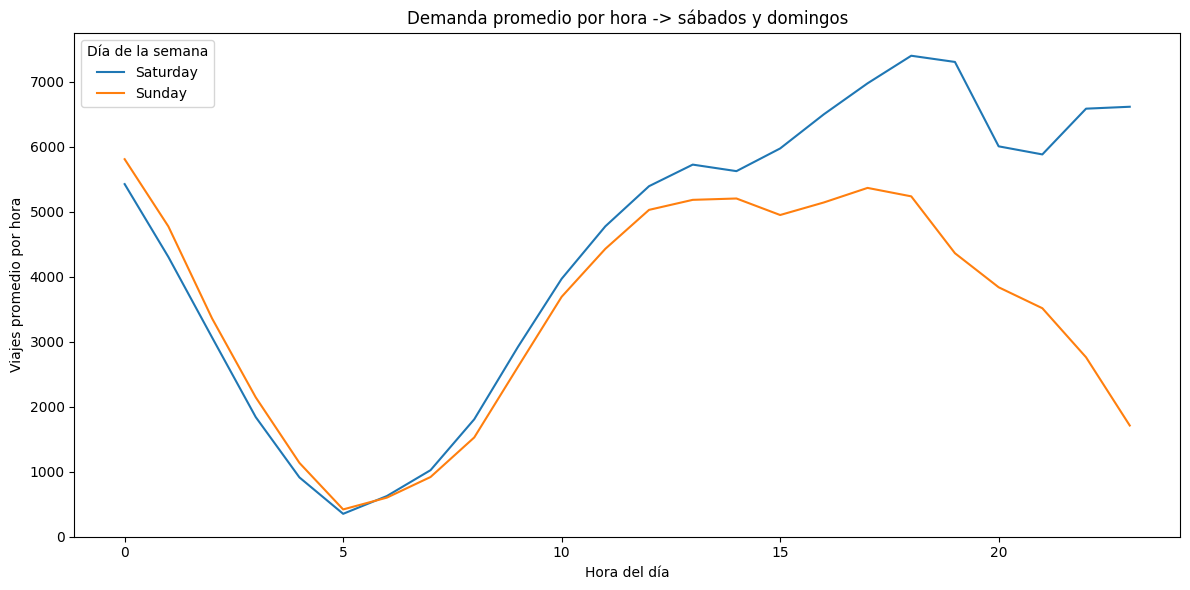

In [57]:
# contar viajes por fecha-hora
df_all['date'] = df_all['pickup_datetime'].dt.date
viajes_hora = df_all.groupby(['date','weekday','hour']).size().reset_index(name='count')

# promedio por hora y weekday
promedio = viajes_hora.groupby(['weekday','hour'])['count'].mean().reset_index()

# Solo consideremos los sábados y domingos
promedio = promedio[promedio['weekday'].isin(['Saturday', 'Sunday'])]

# ordenar días
dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
#promedio['weekday'] = pd.Categorical(promedio['weekday'], categories=dias, ordered=True)

plt.figure(figsize=(12,6))
sns.lineplot(data=promedio, x='hour', y='count', hue='weekday')
plt.title("Demanda promedio por hora -> sábados y domingos")
plt.xlabel("Hora del día"); plt.ylabel("Viajes promedio por hora")
plt.legend(title="Día de la semana")
plt.tight_layout()
plt.show()

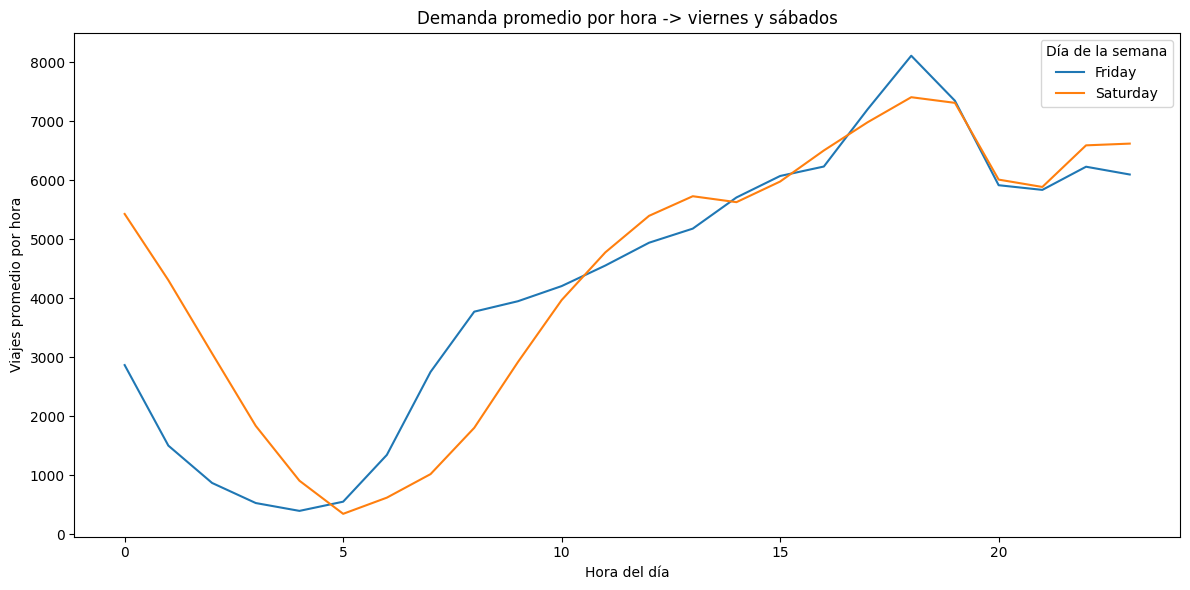

In [58]:
# contar viajes por fecha-hora
df_all['date'] = df_all['pickup_datetime'].dt.date
viajes_hora = df_all.groupby(['date','weekday','hour']).size().reset_index(name='count')

# promedio por hora y weekday
promedio = viajes_hora.groupby(['weekday','hour'])['count'].mean().reset_index()

# Solo consideremos los viernes y sábados
promedio = promedio[promedio['weekday'].isin(['Friday','Saturday'])]

# ordenar días
dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
#promedio['weekday'] = pd.Categorical(promedio['weekday'], categories=dias, ordered=True)

plt.figure(figsize=(12,6))
sns.lineplot(data=promedio, x='hour', y='count', hue='weekday')
plt.title("Demanda promedio por hora -> viernes y sábados")
plt.xlabel("Hora del día"); plt.ylabel("Viajes promedio por hora")
plt.legend(title="Día de la semana")
plt.tight_layout()
plt.show()

------------------------------------

Mejor normalicemos la dda por hora, dividir la dda de cada hora por el total diario, para asi ver si el patrón de horario varía o no. Ya sabemos que la cantidad demandada cambia, pero puede ser que el patrón siga siendo el mismo, por lo que bastaría un factor de escala.

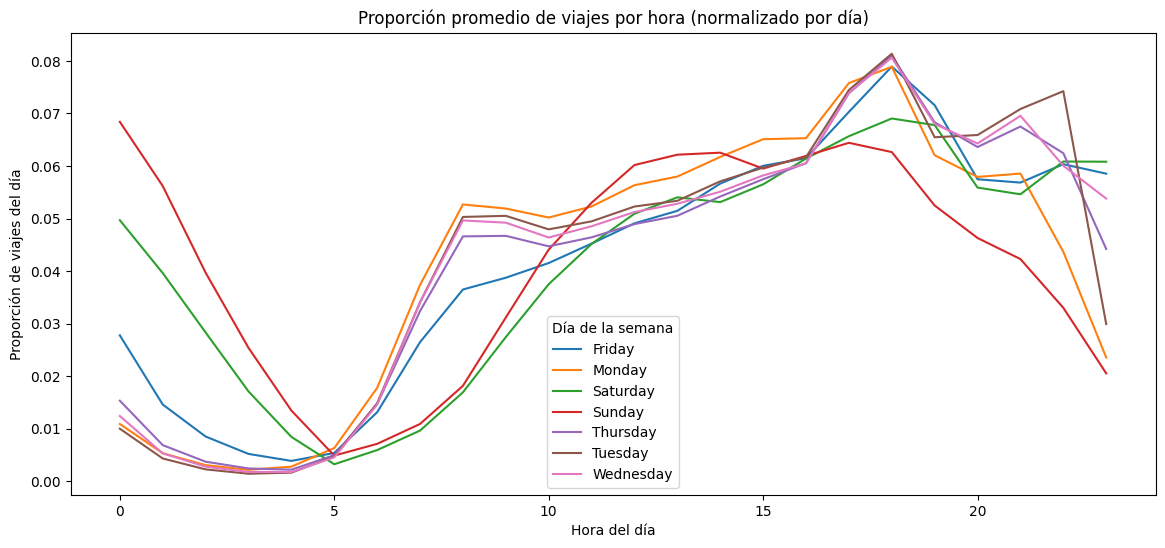

In [59]:
# Normalizar demanda por hora (proporción dentro de cada día)
df_daily = df_all.groupby(['date', 'hour']).size().reset_index(name='count')
df_daily['total_day'] = df_daily.groupby('date')['count'].transform('sum')
df_daily['prop'] = df_daily['count'] / df_daily['total_day']

# Promedio de proporción por hora y día de la semana
df_prop = df_daily.merge(df_all[['date','weekday']].drop_duplicates(), on='date')
promedio_prop = df_prop.groupby(['weekday','hour'])['prop'].mean().reset_index()

# Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=promedio_prop, x='hour', y='prop', hue='weekday')
plt.title("Proporción promedio de viajes por hora (normalizado por día)")
plt.xlabel("Hora del día")
plt.ylabel("Proporción de viajes del día")
plt.legend(title="Día de la semana")
plt.show()

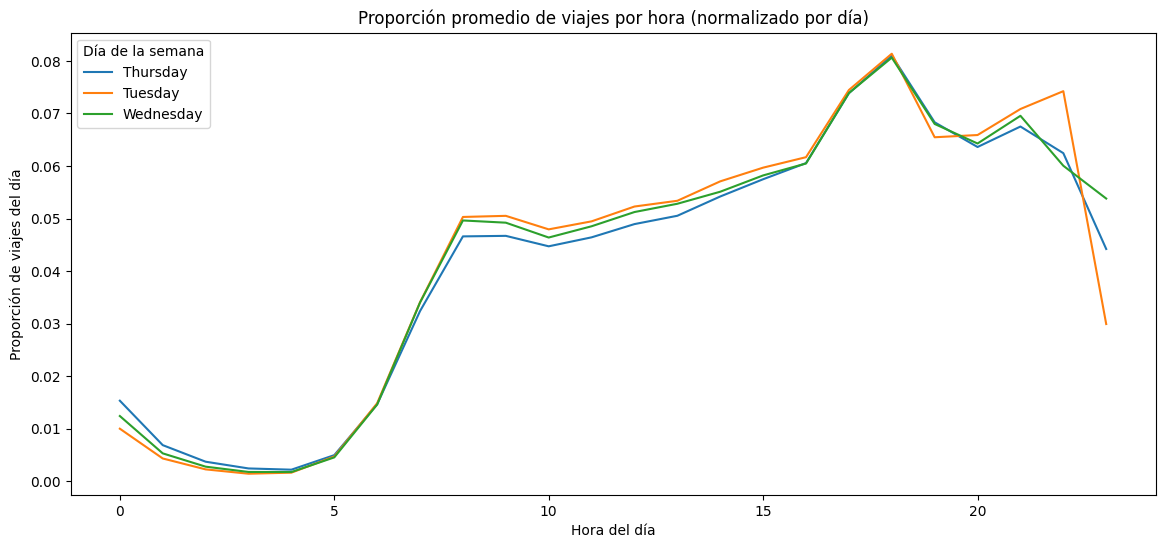

In [60]:
# Normalizar demanda por hora (proporción dentro de cada día)
df_daily = df_all.groupby(['date', 'hour']).size().reset_index(name='count')
df_daily['total_day'] = df_daily.groupby('date')['count'].transform('sum')
df_daily['prop'] = df_daily['count'] / df_daily['total_day']

# Promedio de proporción por hora y día de la semana
df_prop = df_daily.merge(df_all[['date','weekday']].drop_duplicates(), on='date')
promedio_prop = df_prop.groupby(['weekday','hour'])['prop'].mean().reset_index()
promedio_prop = promedio_prop[promedio_prop['weekday'].isin(['Tuesday', 'Wednesday', 'Thursday'])]

# Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=promedio_prop, x='hour', y='prop', hue='weekday')
plt.title("Proporción promedio de viajes por hora (normalizado por día)")
plt.xlabel("Hora del día")
plt.ylabel("Proporción de viajes del día")
plt.legend(title="Día de la semana")
plt.show()

-------------------------------

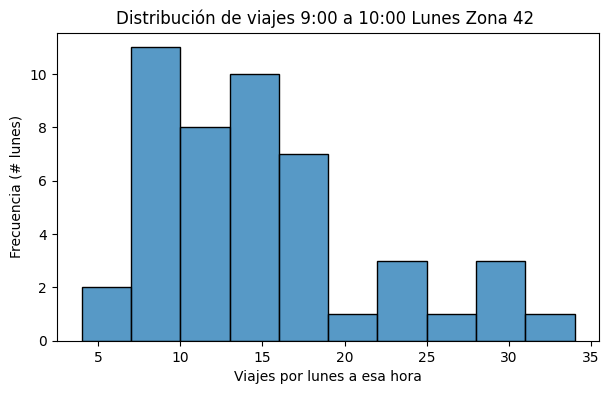

count    47.000000
mean     14.553191
std       6.924464
min       4.000000
25%       9.000000
50%      13.000000
75%      18.000000
max      34.000000
dtype: float64


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Partir de df_all original
df = df_all.copy()

# Asegurar que datetime esté en datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Filtrar solo Lunes
df_lunes = df[df['pickup_datetime'].dt.day_name() == "Monday"].copy()
df_lunes = df_lunes[df_lunes['PUlocationID'] == 42].copy()

# Agrupar por fecha y hora -> número de viajes cada lunes-hora
df_lunes['date'] = df_lunes['pickup_datetime'].dt.date
df_lunes['hour'] = df_lunes['pickup_datetime'].dt.hour
viajes_lunes = df_lunes.groupby(['date','hour']).size().reset_index(name='count')

mask = (df['pickup_datetime'].dt.day_name() == "Monday") & (df['PUlocationID'] == 42)
x = (df.loc[mask & (df['hour'] == 9)]
       .groupby('date')
       .size())

plt.figure(figsize=(7,4))
sns.histplot(x, bins=10, edgecolor="black")
plt.title(f"Distribución de viajes 9:00 a 10:00 Lunes Zona 42 ")
plt.xlabel("Viajes por lunes a esa hora")
plt.ylabel("Frecuencia (# lunes)")
plt.show()

print(x.describe())

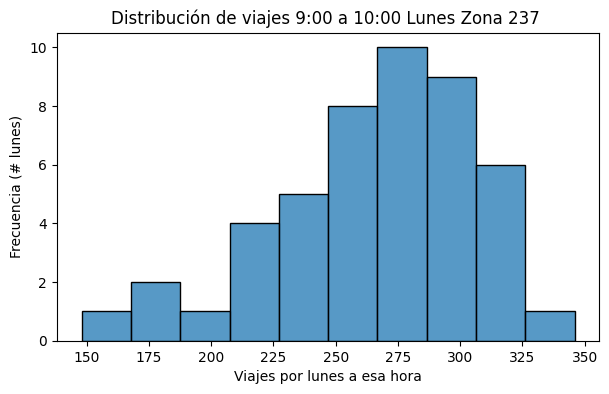

count     47.000000
mean     265.446809
std       40.465126
min      148.000000
25%      242.000000
50%      270.000000
75%      293.500000
max      346.000000
dtype: float64


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Partir de df_all original
df = df_all.copy()

# Asegurar que datetime esté en datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Filtrar solo Lunes
df_lunes = df[df['pickup_datetime'].dt.day_name() == "Monday"].copy()
df_lunes = df_lunes[df_lunes['PUlocationID'] == 237].copy()

# Agrupar por fecha y hora -> número de viajes cada lunes-hora
df_lunes['date'] = df_lunes['pickup_datetime'].dt.date
df_lunes['hour'] = df_lunes['pickup_datetime'].dt.hour
viajes_lunes = df_lunes.groupby(['date','hour']).size().reset_index(name='count')

mask = (df['pickup_datetime'].dt.day_name() == "Monday") & (df['PUlocationID'] == 237)
x = (df.loc[mask & (df['hour'] == 9)]
       .groupby('date')
       .size())

plt.figure(figsize=(7,4))
sns.histplot(x, bins=10, edgecolor="black")
plt.title(f"Distribución de viajes 9:00 a 10:00 Lunes Zona 237 ")
plt.xlabel("Viajes por lunes a esa hora")
plt.ylabel("Frecuencia (# lunes)")
plt.show()

print(x.describe())

In [63]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [64]:
#eliminar feriado usa de df_all
import pandas as pd
import holidays

# Asegurar datetime
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['date'] = df_all['pickup_datetime'].dt.date

# Crear conjunto de feriados en USA (ej: New York)
us_holidays = holidays.US(years=df_all['pickup_datetime'].dt.year.unique(), state='NY')
# Filtrar quitando feriados
df_all = df_all[~df_all['date'].isin(us_holidays)]

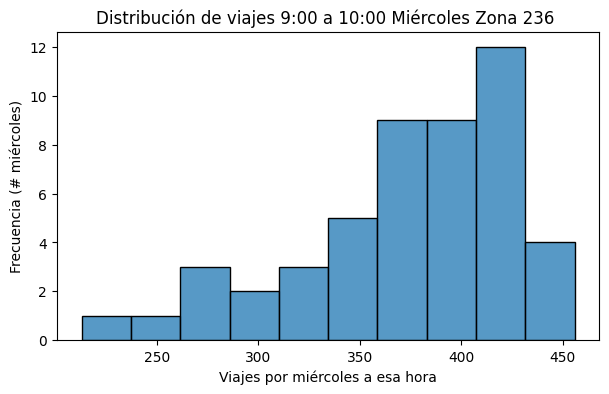

count     49.000000
mean     373.346939
std       56.216305
min      213.000000
25%      348.000000
50%      388.000000
75%      418.000000
max      456.000000
dtype: float64


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Partir de df_all original
df = df_all.copy()

# Asegurar que datetime esté en datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Filtrar solo Lunes
df_lunes = df[df['pickup_datetime'].dt.day_name() == "Wednesday"].copy()
df_lunes = df_lunes[df_lunes['PUlocationID'] == 236].copy()

# Agrupar por fecha y hora -> número de viajes cada lunes-hora
df_lunes['date'] = df_lunes['pickup_datetime'].dt.date
df_lunes['hour'] = df_lunes['pickup_datetime'].dt.hour
viajes_lunes = df_lunes.groupby(['date','hour']).size().reset_index(name='count')

mask = (df['pickup_datetime'].dt.day_name() == "Wednesday") & (df['PUlocationID'] == 236)
x = (df.loc[mask & (df['hour'] == 9)]
       .groupby('date')
       .size())
#subset = viajes_lunes[viajes_lunes['hour'].between(9, 10)]

plt.figure(figsize=(7,4))
sns.histplot(x, bins=10, edgecolor="black")
plt.title(f"Distribución de viajes 9:00 a 10:00 Miércoles Zona 236 ")
plt.xlabel("Viajes por miércoles a esa hora")
plt.ylabel("Frecuencia (# miércoles)")
plt.show()

print(x.describe())

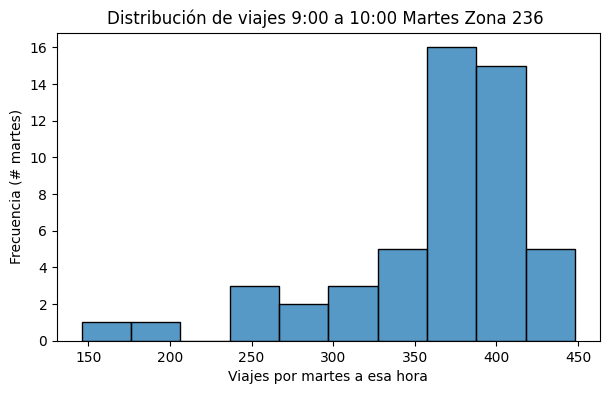

count     51.000000
mean     363.588235
std       62.787635
min      146.000000
25%      349.000000
50%      383.000000
75%      407.500000
max      448.000000
dtype: float64


In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Partir de df_all original
df = df_all.copy()

# Asegurar que datetime esté en datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Filtrar solo Martes
df_lunes = df[df['pickup_datetime'].dt.day_name() == "Tuesday"].copy()
df_lunes = df_lunes[df_lunes['PUlocationID'] == 236].copy()

# Agrupar por fecha y hora -> número de viajes cada lunes-hora
df_lunes['date'] = df_lunes['pickup_datetime'].dt.date
df_lunes['hour'] = df_lunes['pickup_datetime'].dt.hour
viajes_lunes = df_lunes.groupby(['date','hour']).size().reset_index(name='count')

mask = (df['pickup_datetime'].dt.day_name() == "Tuesday") & (df['PUlocationID'] == 236)
x = (df.loc[mask & (df['hour'] == 9)]
       .groupby('date')
       .size())

plt.figure(figsize=(7,4))
sns.histplot(x, bins=10, edgecolor="black")
plt.title(f"Distribución de viajes 9:00 a 10:00 Martes Zona 236 ")
plt.xlabel("Viajes por martes a esa hora")
plt.ylabel("Frecuencia (# martes)")
plt.show()

print(x.describe())

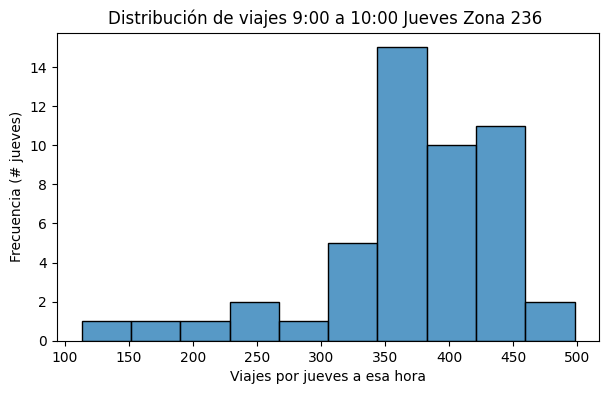

count     49.000000
mean     370.673469
std       74.152823
min      113.000000
25%      348.000000
50%      381.000000
75%      421.000000
max      498.000000
dtype: float64


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Partir de df_all original
df = df_all.copy()

# Asegurar que datetime esté en datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Filtrar solo Jueves
df_lunes = df[df['pickup_datetime'].dt.day_name() == "Thursday"].copy()
df_lunes = df_lunes[df_lunes['PUlocationID'] == 236].copy()

# Agrupar por fecha y hora -> número de viajes cada jueves-hora
df_lunes['date'] = df_lunes['pickup_datetime'].dt.date
df_lunes['hour'] = df_lunes['pickup_datetime'].dt.hour
viajes_lunes = df_lunes.groupby(['date','hour']).size().reset_index(name='count')

mask = (df['pickup_datetime'].dt.day_name() == "Thursday") & (df['PUlocationID'] == 236)
x = (df.loc[mask & (df['hour'] == 9)]
       .groupby('date')
       .size())

plt.figure(figsize=(7,4))
sns.histplot(x, bins=10, edgecolor="black")
plt.title(f"Distribución de viajes 9:00 a 10:00 Jueves Zona 236 ")
plt.xlabel("Viajes por jueves a esa hora")
plt.ylabel("Frecuencia (# jueves)")
plt.show()

print(x.describe())

-----------------------------
-----------------------------
-----------------------------

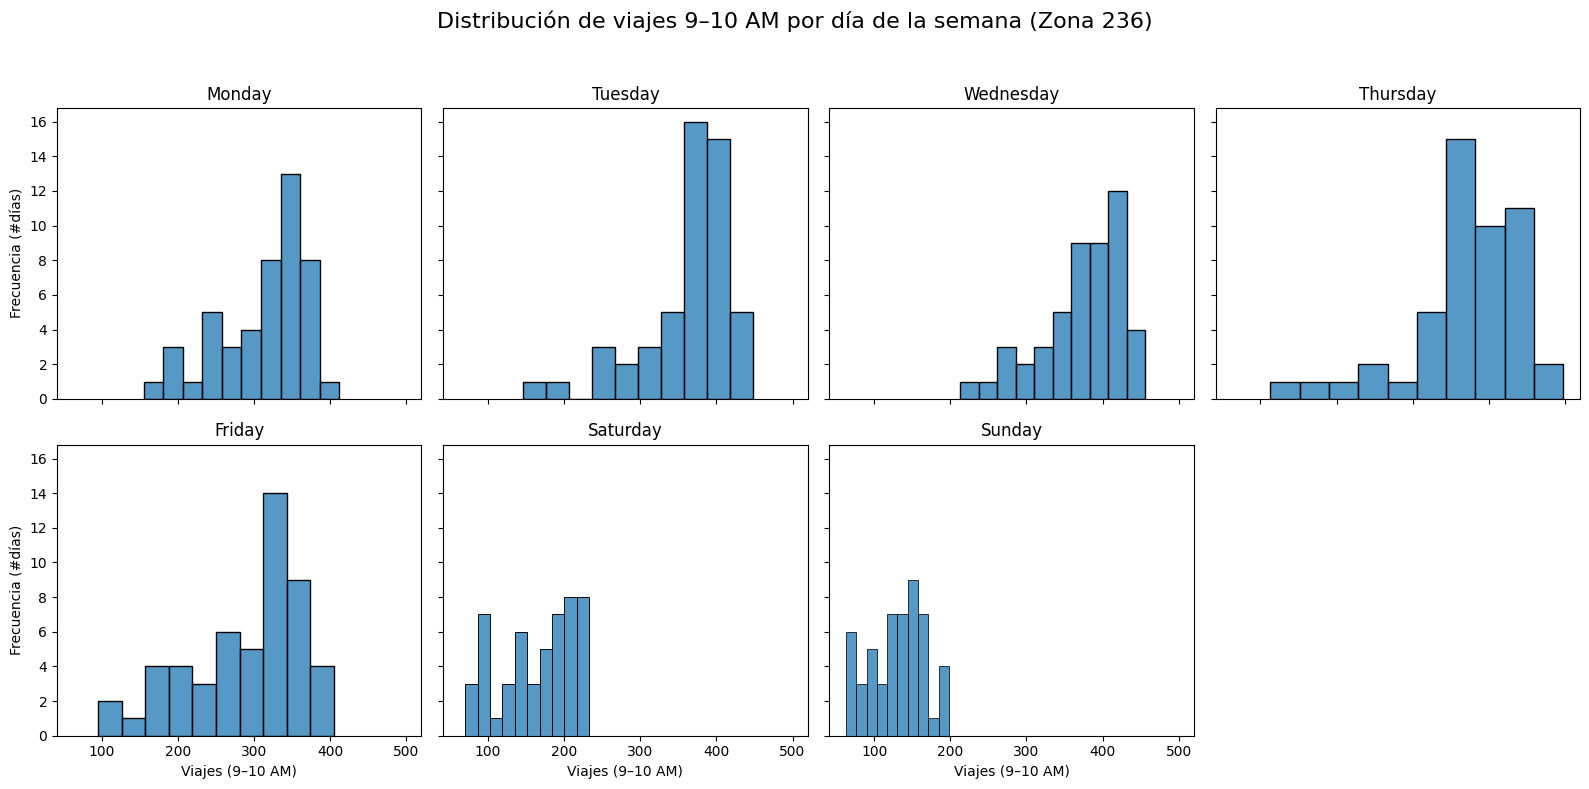

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copiar base
df = df_all.copy()
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Filtrar solo zona específica
df = df[df['PUlocationID'] == 236].copy()

# Agregar columnas auxiliares
df['date'] = df['pickup_datetime'].dt.date
df['hour'] = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.day_name()

# Agrupar: viajes por día-hora
viajes = df.groupby(['date','hour','weekday']).size().reset_index(name='count')

# Subset: solo franja 9–10 AM
subset = viajes[viajes['hour'] == 9]

# Orden de días
dias_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# --- Graficar ---
fig, axes = plt.subplots(2, 4, figsize=(16,8), sharex=True, sharey=True)
axes = axes.flatten()

for i, dia in enumerate(dias_orden):
    data = subset[subset['weekday'] == dia]
    sns.histplot(data['count'], bins=10, edgecolor="black", ax=axes[i])
    axes[i].set_title(dia)
    axes[i].set_xlabel("Viajes (9–10 AM)")
    axes[i].set_ylabel("Frecuencia (#días)")

# Eliminar subplot vacío
fig.delaxes(axes[-1])

plt.suptitle("Distribución de viajes 9–10 AM por día de la semana (Zona 236)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

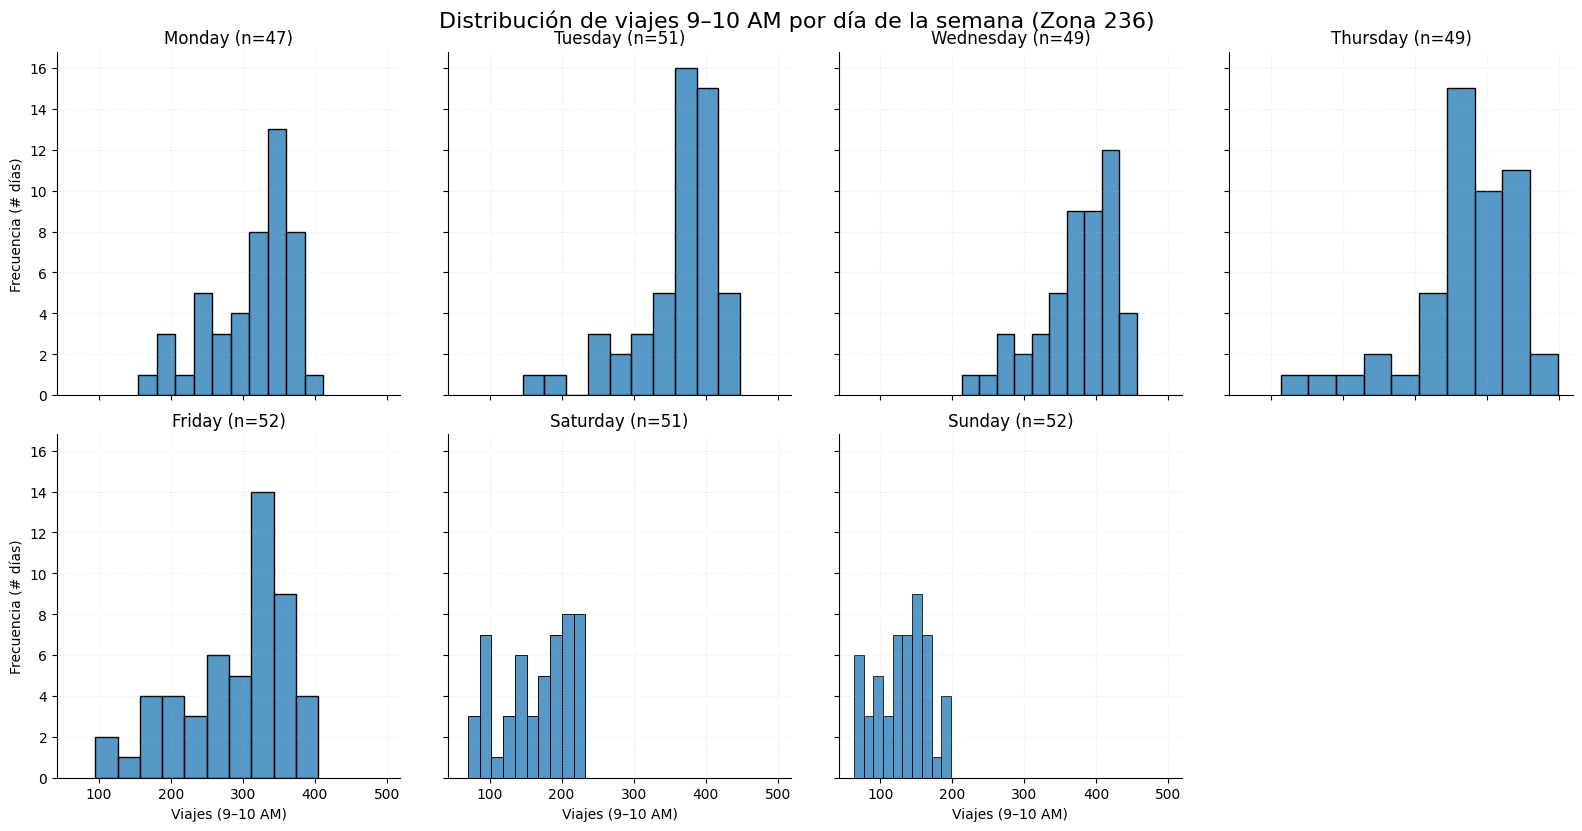

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Base y filtros ---
df = df_all.copy()
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df = df[df['PUlocationID'] == 236].copy()

df['date']    = df['pickup_datetime'].dt.date
df['hour']    = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.day_name()

# Viajes por día-hora
viajes = df.groupby(['date','hour','weekday']).size().reset_index(name='count')

# Solo franja 9–10 (la hora 9)
subset = viajes[viajes['hour'] == 9].copy()

dias_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Rango común de ejes
xmin = subset['count'].min()
xmax = subset['count'].max()
xr = xmax - xmin
pad = max(5, int(0.05 * xr))  # un pequeño margen
xlim = (xmin - pad, xmax + pad)

# --- Plot: 2 filas x 4 columnas (1 vacío), con subplots "cuadrados" ---
fig, axes = plt.subplots(
    2, 4, figsize=(16,8), sharex=True, sharey=True, constrained_layout=True
)
axes = axes.flatten()

for i, day in enumerate(dias_orden):
    ax = axes[i]
    data = subset.loc[subset['weekday'] == day, 'count']

    # Histograma
    sns.histplot(data, bins=10, edgecolor="black", ax=ax)

    # Estética
    ax.set_title(f"{day} (n={len(data)})", fontsize=12)
    ax.set_xlabel("Viajes (9–10 AM)")
    ax.set_ylabel("Frecuencia (# días)")
    ax.set_xlim(xlim)
    ax.grid(alpha=0.25, linestyle=':', linewidth=0.8)
    ax.spines[['top','right']].set_visible(False)

    # Hace cada subgráfico cuadrado (más “proporcionado”)
    try:
        ax.set_box_aspect(1)   # Matplotlib >= 3.4
    except Exception:
        pass

# Oculta el panel sobrante (8º)
fig.delaxes(axes[-1])

plt.suptitle("Distribución de viajes 9–10 AM por día de la semana (Zona 236)", fontsize=16, y=1.02)
plt.show()

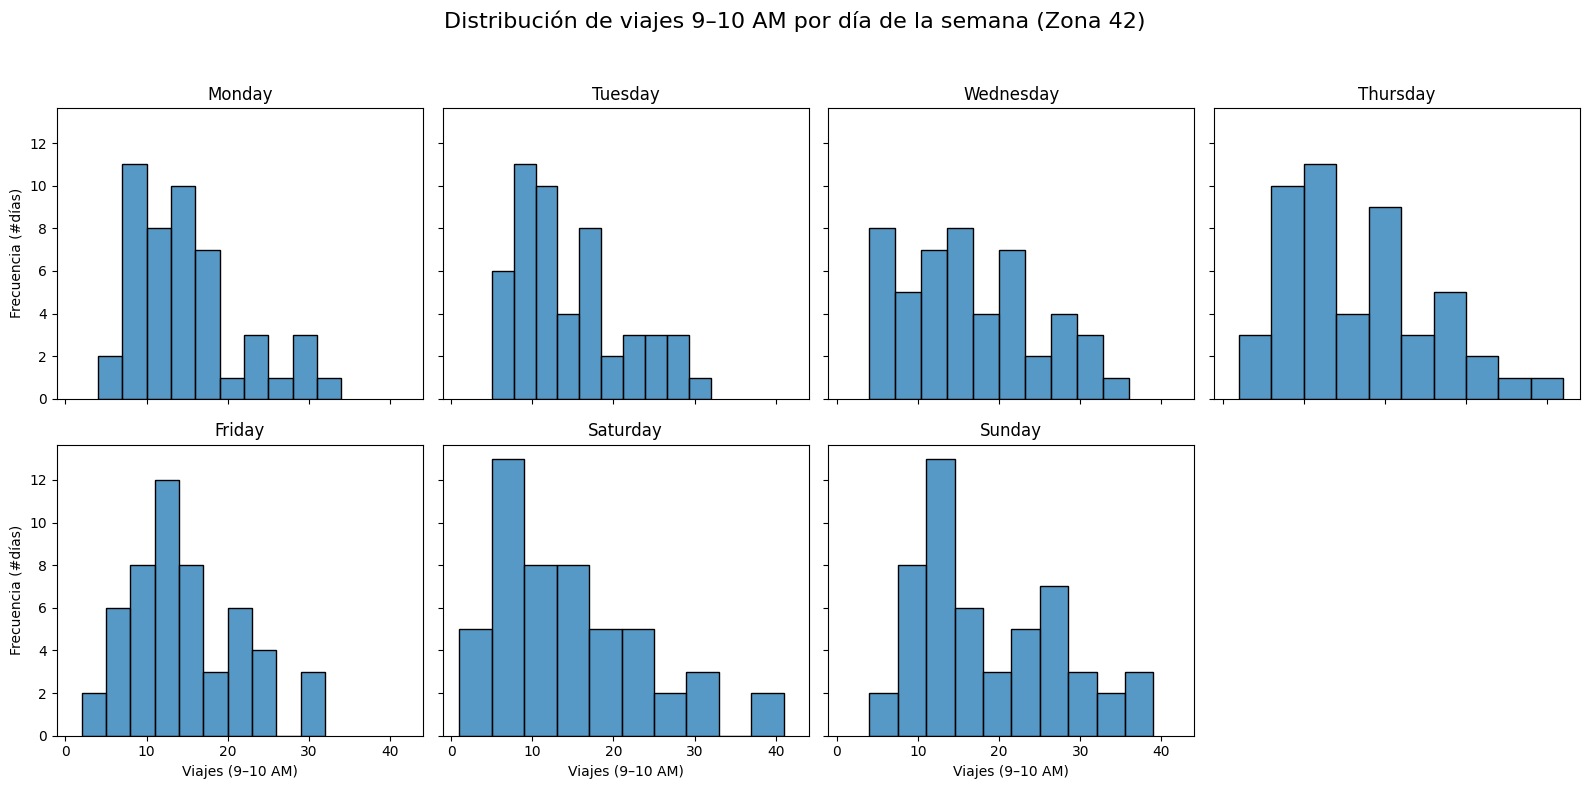

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Copiar base
df = df_all.copy()
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# Filtrar solo zona específica
df = df[df['PUlocationID'] == 42].copy()

# Agregar columnas auxiliares
df['date'] = df['pickup_datetime'].dt.date
df['hour'] = df['pickup_datetime'].dt.hour
df['weekday'] = df['pickup_datetime'].dt.day_name()

# Agrupar: viajes por día-hora
viajes = df.groupby(['date','hour','weekday']).size().reset_index(name='count')

# Subset: solo franja 9–10 AM
subset = viajes[viajes['hour'] == 9]

# Orden de días
dias_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# --- Graficar ---
fig, axes = plt.subplots(2, 4, figsize=(16,8), sharex=True, sharey=True)
axes = axes.flatten()

for i, dia in enumerate(dias_orden):
    data = subset[subset['weekday'] == dia]
    sns.histplot(data['count'], bins=10, edgecolor="black", ax=axes[i])
    axes[i].set_title(dia)
    axes[i].set_xlabel("Viajes (9–10 AM)")
    axes[i].set_ylabel("Frecuencia (#días)")

# Eliminar subplot vacío
fig.delaxes(axes[-1])

plt.suptitle("Distribución de viajes 9–10 AM por día de la semana (Zona 42)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

-----------------------------------------
-----------------------------------------
-----------------------------------------
-----------------------------------------

/var/folders/8d/l8gb32fj0t9792hbywcsbd9w0000gn/T/ipykernel_48643/3247940509.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promedio_mes, x='mes_año', y='count', palette='crest')


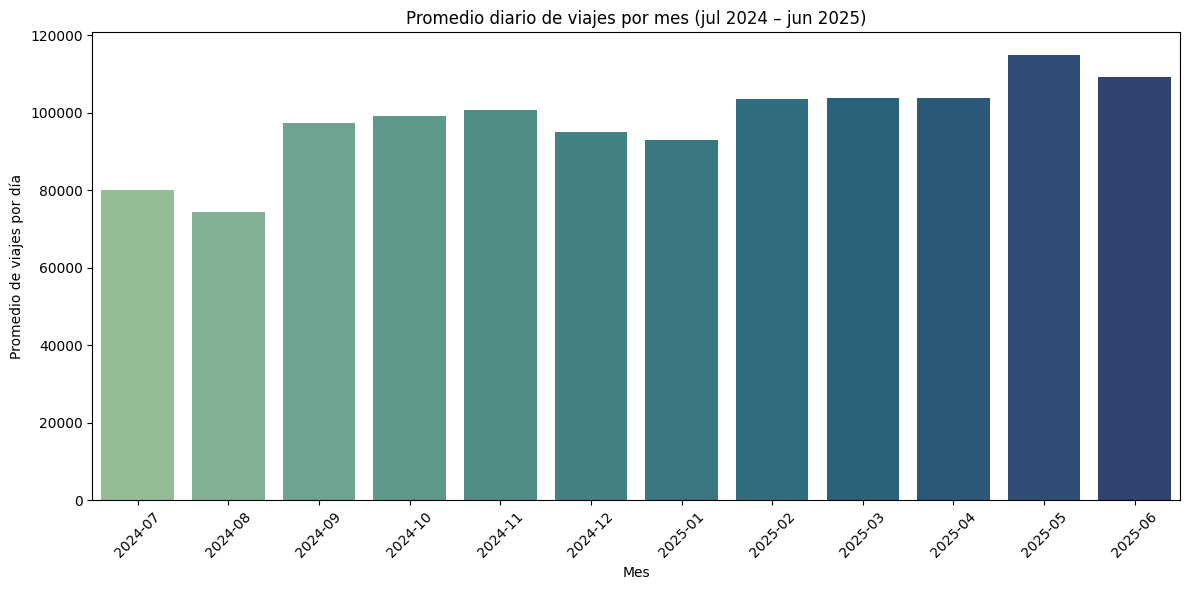

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegura que pickup_datetime es datetime
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['month'] = df_all['pickup_datetime'].dt.month
df_all['year'] = df_all['pickup_datetime'].dt.year

# Filtra solo julio 2024 a junio 2025
df_12m = df_all[
    ((df_all['year'] == 2024) & (df_all['month'] >= 7)) |
    ((df_all['year'] == 2025) & (df_all['month'] <= 6))
].copy()

# Calcula viajes por día
df_12m['date'] = df_12m['pickup_datetime'].dt.date
viajes_por_dia = df_12m.groupby(['year','month','date']).size().reset_index(name='count')

# Promedio diario por mes
promedio_mes = viajes_por_dia.groupby(['year','month'])['count'].mean().reset_index()

# Ordena meses para el gráfico
promedio_mes['mes_año'] = promedio_mes['year'].astype(str) + '-' + promedio_mes['month'].astype(str).str.zfill(2)
promedio_mes = promedio_mes.sort_values(['year','month'])

# Etiquetas de meses
import calendar
promedio_mes['mes_nombre'] = promedio_mes['month'].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(12,6))
sns.barplot(data=promedio_mes, x='mes_año', y='count', palette='crest')
plt.xticks(rotation=45)
plt.xlabel('Mes')
plt.ylabel('Promedio de viajes por día')
plt.title('Promedio diario de viajes por mes (jul 2024 – jun 2025)')
plt.tight_layout()
plt.show()

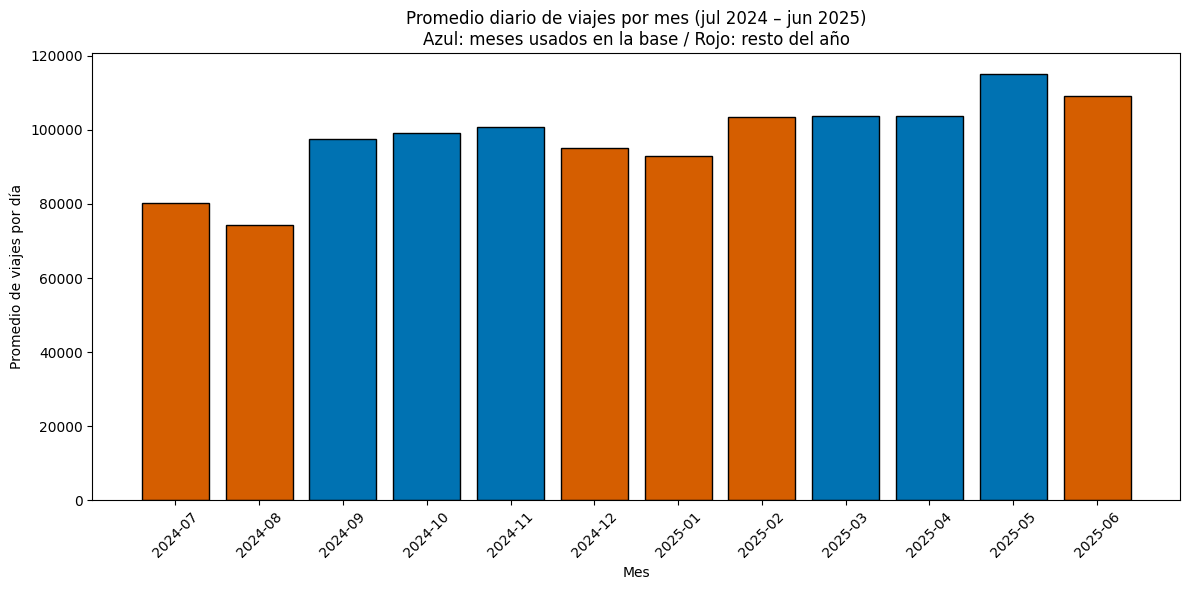

In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar

# Asegura que pickup_datetime es datetime
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['month'] = df_all['pickup_datetime'].dt.month
df_all['year'] = df_all['pickup_datetime'].dt.year

# Filtra solo julio 2024 a junio 2025
df_12m = df_all[
    ((df_all['year'] == 2024) & (df_all['month'] >= 7)) |
    ((df_all['year'] == 2025) & (df_all['month'] <= 6))
].copy()

# Calcula viajes por día
df_12m['date'] = df_12m['pickup_datetime'].dt.date
viajes_por_dia = df_12m.groupby(['year','month','date']).size().reset_index(name='count')

# Promedio diario por mes
promedio_mes = viajes_por_dia.groupby(['year','month'])['count'].mean().reset_index()

# Ordena meses para el gráfico
promedio_mes['mes_año'] = promedio_mes['year'].astype(str) + '-' + promedio_mes['month'].astype(str).str.zfill(2)
promedio_mes = promedio_mes.sort_values(['year','month'])

# Etiquetas de meses
promedio_mes['mes_nombre'] = promedio_mes['month'].apply(lambda x: calendar.month_abbr[x])

# Definir meses de primavera y otoño
meses_azul = [
    (2024, 9), (2024, 10), (2024, 11),  # Sep, Oct, Nov 2024
    (2025, 3), (2025, 4), (2025, 5)     # Mar, Abr, May 2025
]
# Asignar color: azul si está en meses_azul, rojo si no
colores = ['#0072B2' if (row.year, row.month) in meses_azul else '#D55E00' for row in promedio_mes.itertuples()]

plt.figure(figsize=(12,6))
bars = plt.bar(
    promedio_mes['mes_año'],
    promedio_mes['count'],
    color=colores,
    edgecolor="black"
)
plt.xticks(rotation=45)
plt.xlabel('Mes')
plt.ylabel('Promedio de viajes por día')
plt.title('Promedio diario de viajes por mes (jul 2024 – jun 2025)\nAzul: meses usados en la base / Rojo: resto del año')
plt.tight_layout()
plt.show()

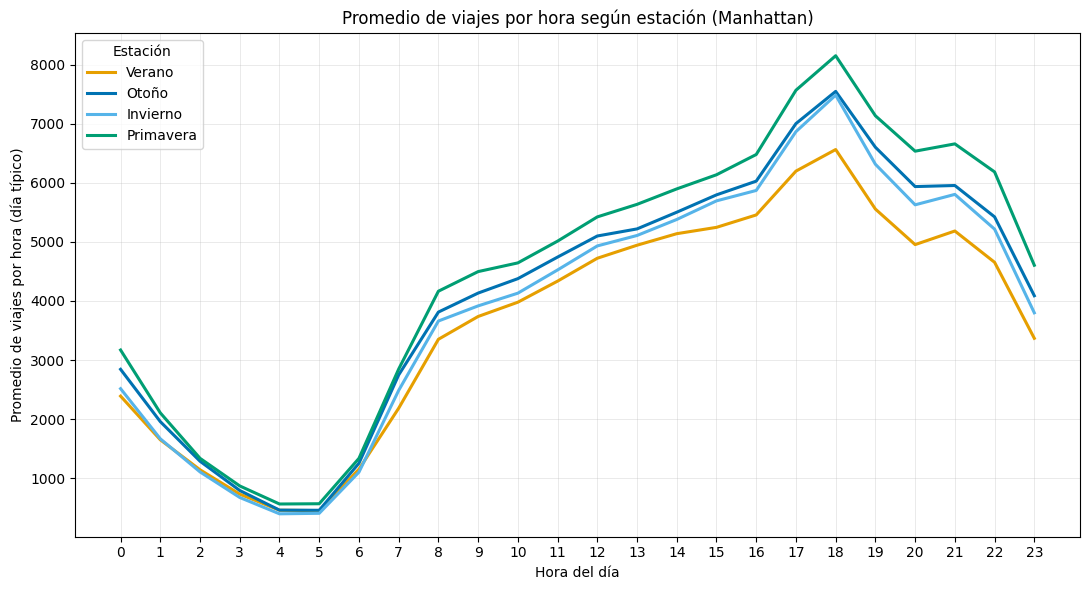

In [73]:
import pandas as pd

import matplotlib.pyplot as plt

# Asegurar columnas necesarias
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['hour'] = df_all['pickup_datetime'].dt.hour
df_all['month'] = df_all['pickup_datetime'].dt.month

# Definir meses por estación (hemisferio norte)
estaciones = {
    'Verano':    [6, 7, 8],
    'Otoño':     [9, 10, 11],
    'Invierno':  [12, 1, 2],
    'Primavera': [3, 4, 5]
}

# Crear columna de estación
def get_estacion(m):
    for est, meses in estaciones.items():
        if m in meses:
            return est
    return None

df_all['estacion'] = df_all['month'].apply(get_estacion)

# Agrupar: promedio de viajes por hora y estación
viajes_estacion = (
    df_all.groupby(['estacion', 'hour'])
    .size()
    .reset_index(name='count')
)

# Normalizar por número de días de cada estación (para hacer promedios comparables)
dias_por_estacion = df_all.groupby('estacion')['pickup_datetime'].apply(lambda x: x.dt.date.nunique()).to_dict()
viajes_estacion['promedio'] = viajes_estacion.apply(
    lambda row: row['count'] / dias_por_estacion[row['estacion']], axis=1
)

# Ordenar estaciones para el gráfico
orden_estaciones = ['Verano', 'Otoño', 'Invierno', 'Primavera']
colores = ['#E69F00', '#0072B2', '#56B4E9', '#009E73']

plt.figure(figsize=(11,6))
for est, color in zip(orden_estaciones, colores):
    datos = viajes_estacion[viajes_estacion['estacion'] == est]
    plt.plot(datos['hour'], datos['promedio'], label=est, linewidth=2.2, color=color)

plt.title("Promedio de viajes por hora según estación (Manhattan)")
plt.xlabel("Hora del día")
plt.ylabel("Promedio de viajes por hora (día típico)")
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend(title='Estación', frameon=True)
plt.tight_layout()
plt.show()




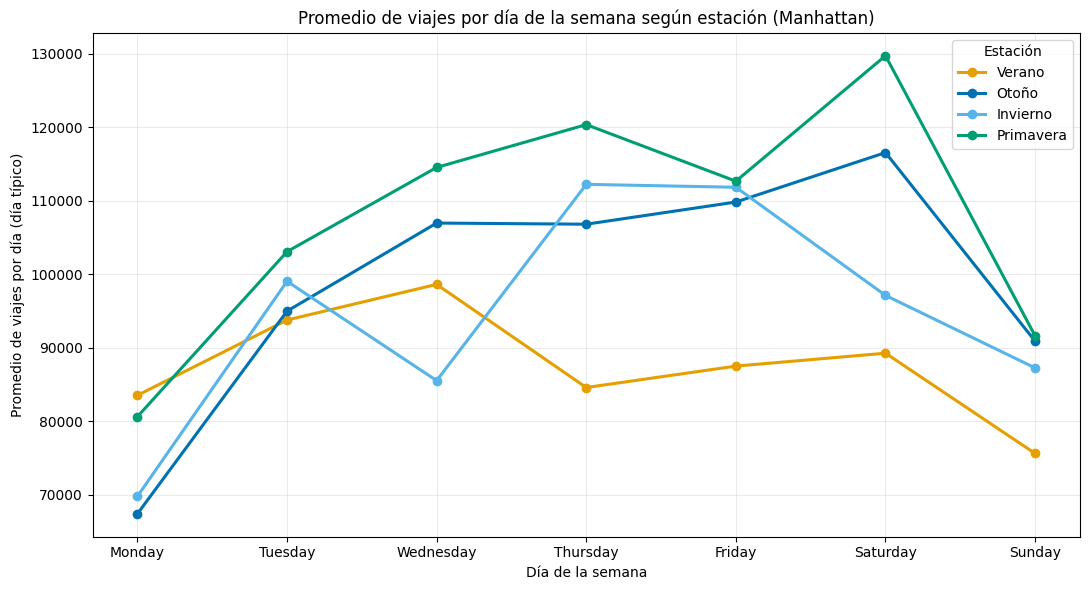

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegura columnas necesarias
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['weekday'] = df_all['pickup_datetime'].dt.day_name()
df_all['month'] = df_all['pickup_datetime'].dt.month

# Definir estaciones (hemisferio norte)
estaciones = {
    'Verano':    [6, 7, 8],
    'Otoño':     [9, 10, 11],
    'Invierno':  [12, 1, 2],
    'Primavera': [3, 4, 5]
}
def get_estacion(m):
    for est, meses in estaciones.items():
        if m in meses:
            return est
    return None

df_all['estacion'] = df_all['month'].apply(get_estacion)

# Agrupar: promedio de viajes por día de la semana y estación
viajes_semana_est = (
    df_all.groupby(['estacion', 'weekday'])
    .size()
    .reset_index(name='count')
)

# Normalizar por número de días de cada estación
dias_por_estacion = df_all.groupby('estacion')['pickup_datetime'].apply(lambda x: x.dt.date.nunique()).to_dict()
viajes_semana_est['promedio'] = viajes_semana_est.apply(
    lambda row: row['count'] / (dias_por_estacion[row['estacion']] / 7), axis=1
)

# Ordenar días y estaciones
dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
viajes_semana_est['weekday'] = pd.Categorical(viajes_semana_est['weekday'], categories=dias_orden, ordered=True)
orden_estaciones = ['Verano', 'Otoño', 'Invierno', 'Primavera']
colores = ['#E69F00', '#0072B2', '#56B4E9', '#009E73']

# Plot
plt.figure(figsize=(11,6))
for est, color in zip(orden_estaciones, colores):
    datos = viajes_semana_est[viajes_semana_est['estacion'] == est]
    plt.plot(dias_orden, datos.sort_values('weekday')['promedio'], label=est, linewidth=2.2, marker='o', color=color)

plt.title("Promedio de viajes por día de la semana según estación (Manhattan)")
plt.xlabel("Día de la semana")
plt.ylabel("Promedio de viajes por día (día típico)")
plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend(title='Estación', frameon=True)
plt.tight_layout()
plt.show()

/var/folders/8d/l8gb32fj0t9792hbywcsbd9w0000gn/T/ipykernel_48643/2994328124.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=viajes_dia_est, x='estacion', y='count', order=orden_estaciones, palette=['#009E73','#E69F00','#0072B2','#56B4E9'])


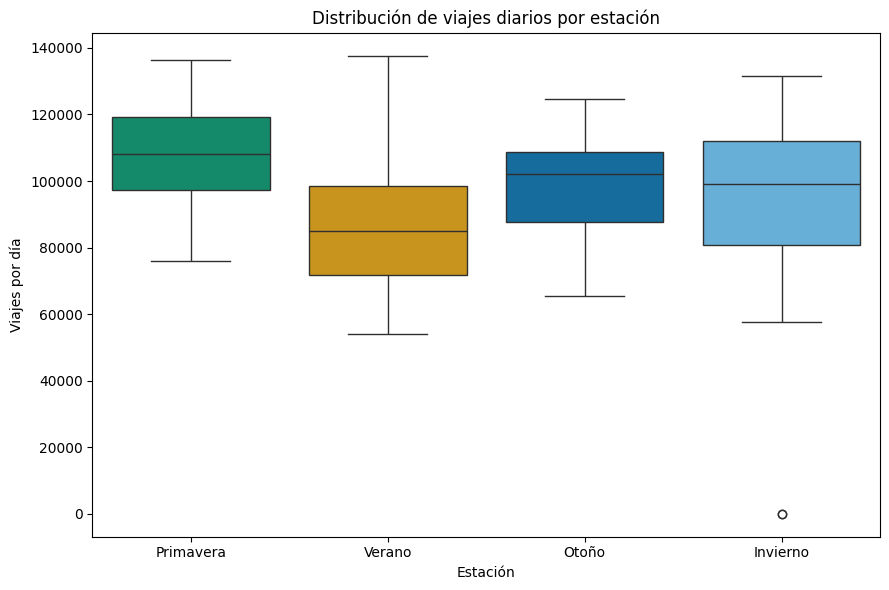

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegura columnas
df_all['pickup_datetime'] = pd.to_datetime(df_all['pickup_datetime'])
df_all['date'] = df_all['pickup_datetime'].dt.date

# Agrupa viajes diarios por estación
viajes_dia_est = (
    df_all.groupby(['estacion', 'date'])
    .size()
    .reset_index(name='count')
)

# Orden de estaciones
orden_estaciones = ['Primavera', 'Verano', 'Otoño', 'Invierno']

plt.figure(figsize=(9,6))
sns.boxplot(data=viajes_dia_est, x='estacion', y='count', order=orden_estaciones, palette=['#009E73','#E69F00','#0072B2','#56B4E9'])
plt.title('Distribución de viajes diarios por estación')
plt.xlabel('Estación')
plt.ylabel('Viajes por día')
plt.tight_layout()
plt.show()

In [77]:
# Estadísticas por estación
stats = viajes_dia_est.groupby('estacion')['count'].agg(['mean','std','min','max'])
print(stats)

                    mean           std    min     max
estacion                                             
Invierno    94674.186047  23829.122729      1  131607
Otoño       99054.034884  13099.253985  65509  124576
Primavera  107512.241758  15558.693094  76043  136460
Verano      87537.100000  20041.038700  53959  137647
